# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

- Автор: Шабанов Виктор
- Дата: 01.12.2025

Целью данного проекта является создание модели по прогнозирванию оттока клиентов для сервиса доставки кофе. Это необходимо для разработки мер по стаблизации клиентской базы, оптимизации маркетингово бюджета и исправления ситуации с постепенным оттоком клиентов.

<a id='sod'></a>
## Содержание

- **[Этап 1. Подготовка среды и библиотек](#inst)**
- **[Этап 2. Первичный анализ данных](#analiz)**
- **[Этап 3. Предобработка данных](#obr)**
- **[Этап 4. Обучение модели](#edu)**
- **[Этап 5. Создание новых признаков](#signs)**
- **[Этап 6. Эксперименты с гиперпараметрами](#giper)**
- **[Этап 7. Подготовка финальной модели](#fin_mod)**
- **[Этап 8. Отчёт о проделанной работе](#otch)**
- **[Этап 9. Сохранение модели для продакшена](#save)**

<a id='inst'></a>
## Этап 1. Подготовка среды и библиотек
1. Установите и настройте библиотеки. Для воспроизводимости результатов зафиксируйте версии пакетов в файле `requirements.txt`.

2. Зафиксируйте `random_state`.

3. Загрузите данные из CSV-файла. Путь к файлу: `'/datasets/coffee_churn_dataset.csv'`. Используйте сепаратор `","`, а для чтения чисел с плавающей точкой — параметр `decimal="."`.

Подключение библиотеки: 

In [1]:
import numpy as np
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

import joblib

from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, average_precision_score
from sklearn.model_selection import cross_validate, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

Зафиксируем `random_state`:

In [2]:
RANDOM_STATE = 42

Загрузим данные для последующего анализа из представленного файла `coffee_churn_dataset.csv`, учитывая при этом сепаратор `","` и разделитель целой и дробной части числовых данных ".". После загрузки покажем характеристики получившегося датасета и выведем пять первых строк.

In [3]:
read_df0 = pd.read_csv('datasets/coffee_churn_dataset.csv', sep=',', decimal='.')
read_df0.info()
read_df0.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  object 
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  object 
 10  preferred_roast           10334 non-null  object 
 11  milk_preference           9782 non-null   object 
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   object 
 14  last_d

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


Датасет содержит 10450 строку и 26 колонок. В строках есть пропуски. Однако, предварительную работу с ними пока проводить не будем, потому что для построения модели нам понадобятся не все колонки, а также не все строки загруженного датасета.

Проверим явные дубликаты:

In [4]:
read_df0.duplicated().sum()

np.int64(0)

Явных дубликатов нет. Это означает, что пока все данные годятся для дальнейшей работы.

*[Содержание](#sod)*

<a id='analiz'></a>
## Этап 2. Первичный анализ данных

1. Опишите данные. Кратко сообщите, что известно о пользователях и их поведении.

2. Опишите целевую переменную. Обратите внимание на возможные особенности её распределения. Проверьте, наблюдается ли дисбаланс классов в целевой переменной.

3. Опишите признаки.

   - Определите, все ли из них важны.

   - Объясните, какие из них можно удалить (если такие есть). Аргументируйте своё решение.

4. Обработайте пропущенные значения.
   
   - Объясните, как они влияют на данные.

   - Выберите стратегию заполнения пропусков.

5. Проанализируйте категориальные признаки.

   - Выясните, есть ли в данных признаки, которые можно кодировать. Объясните, почему именно их нужно кодировать.

   - Проанализируйте признаки на предмет того, можно ли использовать некоторые из них для генерации новых  признаков. Укажите возможные стратегии.

   - Определите, есть ли в данных признаки, которые можно удалить.

6. Проанализируйте выбросы.

   - Определите, как они влияют на данные.

   - Выберите способ, которым их можно обработать.

7. Посчитайте корреляции между признаками. Постройте необходимые визуализации. Определите, есть ли признаки, которые можно убрать, на основании их корреляции с другими.

8. Напишите выводы по результатам исследовательского анализа данных.

Данные были собраны из внутренних систем компании: транзакционной базы данных, логов мобильного приложения и результатов опросов. Судя по заданию, данные обладают следующими особенностями:

- **Период агрегации.** Признаки агрегирваны за последние 4 недели.
- **Формат данных.** Данные представлены в виде готовой аналитической витрины. Это означает, что для каждого клиента уже рассчитаны и собраны в одну строку все необходимые для моделирования признаки.
- **Стуктура.** Каждая строка — это один уникальный клиент. Все признаки уже вычислены и представлены в виде числовых и категориальных значений.

По поводу поведения клиентов в задании к проекту отмечалось, что было замечено, что каждый месяц сервис доставки кофе теряет 10% клиентской базы, что напрямую снижает ежемесячную выручку.

Исходя из приоритетов нашего проекта целевой переменной безусловно является `churn`, которая должна быть бинарной и отображать факт: перестал ли пользователь пользоваться сервисом. Проверим, есть ли пропуски в колонке `churn`:

In [5]:
read_df0['churn'].isna().sum()

np.int64(0)

Пропусков нет. Значит, пока по отношению к целевой переменной все данные годятся для дальнейшей работы. Теперь проверим уникальные значения в колонке `churn`:

In [6]:
read_df0['churn'].unique()

array([1, 0])

Колонка действительно является бинарой и годится по содержанию для создания модели. Неожиданных значений нет.

Теперь посмотрим количество значений каждого класса (0, 1) и их доли в общем количестве:

In [7]:
classes = read_df0['churn'].value_counts().to_frame()
classes.columns = ['churn']
classes['Доля'] = round(classes['churn'] / classes['churn'].sum() * 100, 2)
classes

,churn,Доля
churn,,
0,9821,93.98
1,629,6.02


Получается, что у классов целевой переменной наблюдается очень большой дисбаланс (всего 6% элементов относятся к положительному классу). Это надо обязательно учесть при создании модели.

Теперь начнем рассматривать потенциальные признаки модели. Первой идет колонка `user_id`. В ней нет пропусков:

In [8]:
read_df0['user_id'].isna().sum()

np.int64(0)

Уникальный идентификатор пользователя хорош для сбора и проверки данных, но никак не связан с поставленной нами задачей, поэтому имя этой колонки добавим первой в список колонок для удаления из рабочего датасета:

In [9]:
del_signs = ['user_id']

Чтобы более осмысленно рассматривать признаки, разделим их на нечисловые и числовые. Нечисловые выберем следующим образом:

In [10]:
list(read_df0.columns[read_df0.dtypes == 'object'])

['user_id',
 'last_coffee_type',
 'preferred_roast',
 'milk_preference',
 'coffee_bean_origin',
 'last_drink_size',
 'subscription_status',
 'seasons',
 'phone_type',
 'geo_location']

Потенциально эти колонки превратятся в категориальные признаки создаваемой модели. Модель не сможет работать с текстовыми полями, поэтому придется воспользоваться тем или иным методом кодирования, чтобы перевести их в числовой формат. 

Колонку `user_id` мы уже рассматривали, поэтому перейдем к слеудющей - `last_coffee_type` (сорт кофе, купленный пользователем в последний раз на момент сбора данных). Уникальные значения в этой колонке приведены ниже:

In [11]:
read_df0['last_coffee_type'].unique()

array(['blend', 'arabica', 'robusta', nan], dtype=object)

Это явно категориальная колонка, содержащая пропуски. Уникальных значений немного поэтому для их кодирования можно воспользоваться методом кодирования **One-Hot Encoding**. Однако, в этом случае ясной логической связи с целевой переменной не просматривается, поэтому принимать решение о включении этого признака в модель лучше после расчета коэффициента корреляции с целевой переменной.

Следующая колонка из нечисловых - это `preferred_roast`(предпочитаемый тип обжарки). Для нее уникальные значения:

In [12]:
read_df0['preferred_roast'].unique()

array(['light', 'medium', 'dark', nan], dtype=object)

Здесь ситуация аналогична предыдущей колонке, поэтому не будем повторяться. Идем дальше. Колонка `milk_preference` (предпочитаемый тип молока):

In [13]:
read_df0['milk_preference'].unique()

array(['almond', 'whole', 'oat', 'skim', 'soy', nan, 'none'], dtype=object)

Категориальный признак с уже большим количеством уникальных значений. Следует отметить, что если все эти категориальные признаки кодировать методом One-Hot Encoding, то модель излишне усложнится. Связь этого признака с целевой переменной также кажетя несяной, поэтому подождем с принятием решения по включению его в модель после расчета корреляции.

Следующая нечисловая колонка `coffee_bean_origin` (страна происхождения зерна):

In [14]:
read_df0['coffee_bean_origin'].unique()

array(['vietnam', 'guatemala', 'brazil', 'colombia', 'kenya', nan,
       'ethiopia'], dtype=object)

Наблюдается та же ситуация, что и для предыдущей колонки. Далее `last_drink_size`:

In [15]:
read_df0['last_drink_size'].unique()

array(['large', 'medium', 'small', nan], dtype=object)

Здесь ситуация аналогична положением с колонкой `last_coffee_type`. Теперь колонка `subscription_status` (тип подписки пользователя):

In [16]:
read_df0['subscription_status'].unique()

array(['pro', 'none', 'premium', 'basic', nan], dtype=object)

Аналогичная ситуация. Следующая колонка `seasons` (текущее время года):

In [17]:
read_df0['seasons'].unique()

array(['summer', 'autumn', 'spring', 'winter', nan], dtype=object)

В данном случае содержимое колонки противоречит периоду агрегации данных. В условиях к проекту сказано, что данные агрегированы за последние четыре недели, а значит временной период агрегации в определенной ситуации может быть на стыке двух календарных месяцев и, как следствие, на стыке двух сезонов года. В данных же мы имеем все четыре сезона года. Значит, непонятно, как интерпретировать описание колонки "текущее время года". Поэтому эту колонку однозначно нужно исключить из модели из-за, возможно, ошибочно интерпретируемых данных. Добавим название этой колонки к списку удаляемых:

In [18]:
del_signs.append('seasons')

Следующая колонка `phone_type` (тип устройства, с которого пользователь чаще всего совершал покупки):

In [19]:
read_df0['phone_type'].unique()

array(['android', 'ios', 'web', nan], dtype=object)

Тут ситуация повторяется, как в случае аналогичных категориальных признаков. Последняя колонка `geo_location` (идентификатор региона пользователя): 

In [20]:
read_df0['geo_location'].unique()

array(['geo_75', 'geo_95', 'geo_25', 'geo_2', 'geo_19', 'geo_68', 'geo_3',
       'geo_45', 'geo_15', nan, 'geo_30', 'geo_93', 'geo_64', 'geo_40',
       'geo_87', 'geo_17', 'geo_11', 'geo_94', 'geo_1', 'geo_50',
       'geo_67', 'geo_51', 'geo_97', 'geo_16', 'geo_78', 'geo_100',
       'geo_98', 'geo_43', 'geo_8', 'geo_48', 'geo_61', 'geo_74',
       'geo_35', 'geo_59', 'geo_46', 'geo_5', 'geo_23', 'geo_91',
       'geo_42', 'geo_90', 'geo_4', 'geo_96', 'geo_57', 'geo_71',
       'geo_54', 'geo_65', 'geo_32', 'geo_14', 'geo_72', 'geo_29',
       'geo_9', 'geo_83', 'geo_12', 'geo_76', 'geo_92', 'geo_84',
       'geo_31', 'geo_34', 'geo_41', 'geo_18', 'geo_24', 'geo_85',
       'geo_49', 'geo_69', 'geo_47', 'geo_86', 'geo_99', 'geo_36',
       'geo_79', 'geo_26', 'geo_73', 'geo_13', 'geo_10', 'geo_58',
       'geo_63', 'geo_82', 'geo_22', 'geo_39', 'geo_81', 'geo_21',
       'geo_27', 'geo_33', 'geo_20', 'geo_60', 'geo_53', 'geo_88',
       'geo_62', 'geo_70', 'geo_28', 'geo_56', 'geo_5

Связь этой колонки с целевой переменной вполне можно себе представить. Метод кодировки же здесь можно предложить нестандартный. Просто убрать префикс `geo_` и сменить тип на `int`. Правда, этот метод не сработает с пропусками. Но для них можно установить признак равным нулю. Правда, такой способ может сделать местоположение с большим номером более значимым, чем меньшим, поэтому лучше все же воспользоваться методом кодирования **Target Encoding**.

Теперь разберем числовые колонки:

In [21]:
num_col = list(read_df0.columns[read_df0.dtypes != 'object'])
num_col

['days_since_last_order',
 'order_frequency_month',
 'order_frequency_week',
 'avg_order_value',
 'median_order_value',
 'total_spent_last_month',
 'total_spent_last_week',
 'discount_usage_rate',
 'seasonal_menu_tried',
 'app_opens_per_week',
 'notifications_enabled',
 'review_rating_last_10',
 'review_rating_last_1',
 'app_crashes_last_month',
 'days_since_last_promo',
 'coffee_preference_change',
 'churn']

В нашем случае числовые колоки можно разделить на три группы: колонки с категориальными битовыми значениями, колонки и колонки с непрерывными числовыми значениями. К первой группе нужно отнести колонки:
- `seasonal_menu_tried` - отметка о том, пробовал ли пользователь новейшее сезонное меню.
- `notifications_enabled` - включены ли у пользователя уведомления.
- `coffee_preference_change` - менялись ли вкусовые предпочтения пользователя.

Убедимся в этом:

In [22]:
cols_bit = ['seasonal_menu_tried', 'notifications_enabled', 'coffee_preference_change']
for col in cols_bit:
    uniq = read_df0['coffee_preference_change'].unique()
    print(f'Колонка: {col} - Уникльные значения: {uniq}')

Колонка: seasonal_menu_tried - Уникльные значения: [ 0.  1. nan]
Колонка: notifications_enabled - Уникльные значения: [ 0.  1. nan]
Колонка: coffee_preference_change - Уникльные значения: [ 0.  1. nan]


Всё правильно. Следует обратить внимание, что в каждой колонке есть пустые значения. Их будем заполнять в обучающей выборке значением класса с большей долей.

Теперь перейдем ко второй группе колонок. В них достаточно много пропусков:

In [23]:
num_col2 = [item for item in num_col if item not in cols_bit]
num_col2.remove('churn')
read_df0[num_col2].isna().sum()

days_since_last_order     945
order_frequency_month     600
order_frequency_week      388
avg_order_value           583
median_order_value        831
total_spent_last_month    294
total_spent_last_week     944
discount_usage_rate       397
app_opens_per_week        896
review_rating_last_10     693
review_rating_last_1      857
app_crashes_last_month    721
days_since_last_promo     731
dtype: int64

В данном случае пропуски будем заменять на средние значения по колонке в обучающей выборке позднее, чтобы не допустить переобучения модели.

Кроме того, среди этих колонок есть пары с одинаковым смыслом, но полученные за разные временные периоды. Первая пара это колонки:
- `order_frequency_month` - среднее число заказов в месяц.
- `order_frequency_week` - среднее число заказов в неделю.

Включение обеих этих колонок в модель неизбежно приведет к мультиколинеарности. Поэтому для модели нужно оставить только одну из этих колонок. Какую именно оставить определим после рассчета коэффициентов корреляции с целевой переменной.

Аналогичная ситуация с колонками:
- `total_spent_last_month` - сумма заказов за последний месяц.
- `total_spent_last_week` - сумма заказов за последнюю неделю.

С ними поступим точно так же.

В другой паре колонок смысл одинаков, но различается метод расчета:
- `avg_order_value` - средний чек, в рублях.
- `median_order_value` - медианный чек, в рублях.

Какую же из этих колонок выбрать для модели? Решение оставим до расчета коэффициентов корреляции. Последняя пара колонок следующая:
- `review_rating_last_10` - средняя оценка последних на момент сбора данных десяти заказов клиента.
- `review_rating_last_1` - оценка последнего на момент сбора данных заказа клиента.

По логике оценка последнего заказа может значительно больше повлиять на уход клиента, чем средняя оценка десяти последних заказов. Поэтому решение о том, какую колонку оставить, как и во всех предыдущих случаях, сделаем после расчета коэффициентов корреляции с целевой переменной.

Так как значения, содержащиеся в колонках датафрейма разнородны и содержат не только непрерывные числовые значения, но и бинарные и категориальные, то для оценки их связи с целевой переменной воспользуемся коэффициентом `phi_k`. Коэффициенты корреляции будем считать для всех колонок, кроме тех, которые мы уже запланировали для удаления (`user_id` и `seasons`). Сразу получим тепловую карту коэффициентов:<a id='zero'></a>

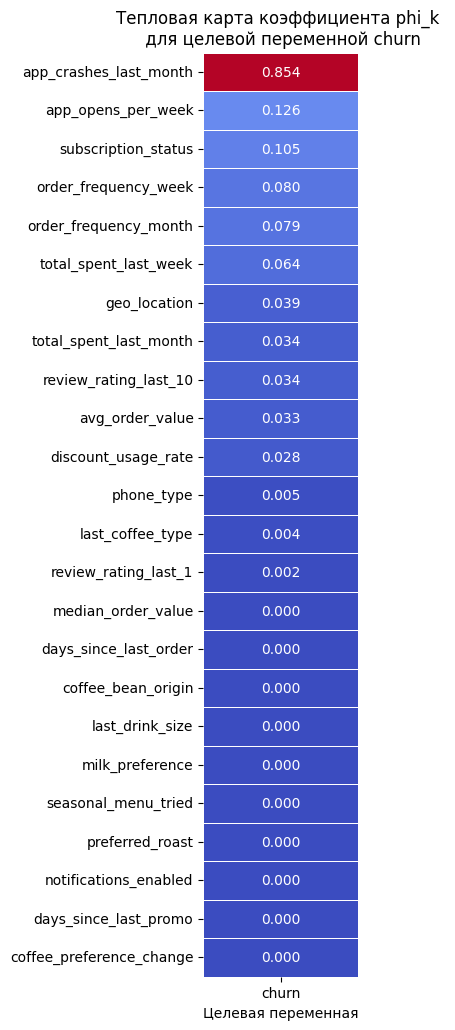

In [24]:
# Список колонок, для которых мы будем считать коэффициенты корреляции
corr_cols = [item for item in list(read_df0.columns) if item not in del_signs]
num_cont_col = num_col2.copy()
num_cont_col.remove('app_crashes_last_month')
# Здесь num_col2 - это список колонок с непрерывными числовыми значениями
phik_corr = read_df0[corr_cols].phik_matrix(interval_cols=num_cont_col)

# Строим тепловую карту
plt.figure(figsize=(2, 12))

# Сохраняем матрицу корреляции признака веса черепахи с количественными признаками
data_heatmap = phik_corr.loc[phik_corr.index != 'churn'][['churn']].sort_values(by='churn', ascending=False)
sns.heatmap(data_heatmap,
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.3f', # Форматируем значения корреляции: три знака после точки
            cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5, # Форматируем линию между ячейками карты
            cbar=False # Отключаем цветовую шкалу
            #rot=0
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n для целевой переменной churn')
plt.xlabel('Целевая переменная')

# Выводим график
plt.show()

Для упрощения дальнейшей работы очень бы хотелось удалить колонки с нулевым коэффициентом корреляции. Однако их сочетание может положительно повлиять на модель. Поэтому не будем делать скоропалительных выводов и оставим их.

Из рассмотренных ранее пар меньший добавляем к удаляемым колонкам исходные колонки, имеющие меньший коэффициент корреляции. 

In [25]:
min_corr = ['order_frequency_month', 'total_spent_last_month', 'review_rating_last_1','median_order_value']
del_signs = del_signs + min_corr

Теперь удалим колонки из списка для удаления в первоначальном датафрейме и получим исходный датафрейм для создания моделей:

In [26]:
df = read_df0[[item for item in list(read_df0.columns) if item not in del_signs]].copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   days_since_last_order     9505 non-null   float64
 1   order_frequency_week      10062 non-null  float64
 2   avg_order_value           9867 non-null   float64
 3   total_spent_last_week     9506 non-null   float64
 4   discount_usage_rate       10053 non-null  float64
 5   last_coffee_type          10192 non-null  object 
 6   preferred_roast           10334 non-null  object 
 7   milk_preference           9782 non-null   object 
 8   seasonal_menu_tried       9461 non-null   float64
 9   coffee_bean_origin        9768 non-null   object 
 10  last_drink_size           9946 non-null   object 
 11  subscription_status       9512 non-null   object 
 12  app_opens_per_week        9554 non-null   float64
 13  notifications_enabled     9913 non-null   float64
 14  review

Из 26 колонок первоначального датафрейма осталась 21. Из них остались следующие категориальные колонки:

In [27]:
cat_col = list(df.columns[df.dtypes == 'object'])
cat_col

['last_coffee_type',
 'preferred_roast',
 'milk_preference',
 'coffee_bean_origin',
 'last_drink_size',
 'subscription_status',
 'phone_type',
 'geo_location']

В них есть пропуски:

In [28]:
# Функция получения датафрейма с пропусками по указанным колонкам
def get_isna(df_, cols_):
    isna_df = df_[cols_].isna().sum().to_frame().reset_index()
    isna_df.columns = ['Колонка','Пропуски']
    isna_df['Доля %'] = (isna_df['Пропуски'] / df_.shape[0] * 100).round(2)
    return isna_df
    
get_isna(df, cat_col)

,Колонка,Пропуски,Доля %
0,last_coffee_type,258,2.47
1,preferred_roast,116,1.11
2,milk_preference,668,6.39
3,coffee_bean_origin,682,6.53
4,last_drink_size,504,4.82
5,subscription_status,938,8.98
6,phone_type,336,3.22
7,geo_location,110,1.05


Максимальная доля пропусков содержится в колонке `subscription_status` - тип подписки пользователя (8.98%). Однако среди уникальных значений в этой колонке есть значение `none` - нет подписки. Логично предположить, что у пользователей, для которых тип подиски пропущен ее просто нет. Поэтому в дальнейшем по этому полю будем заполнять пропуски значением `none`.

Для других категориальных колонок доля пропусков невелика, поэтому будем заполнять их значением категории с большим количеством записей среди всех записей в обучающей выборке. Такой подход позволит избежать утечки информации при использовании модели.

Модель не сможет оперировать тестовыми данными. Их нужно перевести в числа. Поэтому нам нужно определиться с методом кодирования. Для этого посмотрим количество уникальных значений для каждой категориальной колонки:

In [29]:
df[cat_col].nunique()

last_coffee_type         3
preferred_roast          3
milk_preference          6
coffee_bean_origin       6
last_drink_size          3
subscription_status      4
phone_type               3
geo_location           100
dtype: int64

В трех первых колонках количество уникальный значений не превышает 6, поэтому для них можно воспользоваться методом кодирования **One-Hot Encoding**. Для геолокации количество уникальных значений составляет сотню, поэтому предыдущим методом уже не воспользуешься. Для этой колонки будем пользоваться методом кодировки **Target Encoding**.

Теперь обратимся к числовым колонкам (из списка исключаем колонку целевой переменной):

In [30]:
num_col = list(df.columns[df.dtypes != 'object'])
num_col.remove('churn')
num_col

['days_since_last_order',
 'order_frequency_week',
 'avg_order_value',
 'total_spent_last_week',
 'discount_usage_rate',
 'seasonal_menu_tried',
 'app_opens_per_week',
 'notifications_enabled',
 'review_rating_last_10',
 'app_crashes_last_month',
 'days_since_last_promo',
 'coffee_preference_change']

Посмотрим количество пропусков в этих колонках:

In [31]:
get_isna(df, num_col)

,Колонка,Пропуски,Доля %
0,days_since_last_order,945,9.04
1,order_frequency_week,388,3.71
2,avg_order_value,583,5.58
3,total_spent_last_week,944,9.03
4,discount_usage_rate,397,3.80
5,seasonal_menu_tried,989,9.46
6,app_opens_per_week,896,8.57
7,notifications_enabled,537,5.14
8,review_rating_last_10,693,6.63
9,app_crashes_last_month,721,6.90


Количество пропусков не превышает 9.04%. Запоним их средними значениями по колонке, воспользовавшись данными обучающей выборки, для преодоления утечки информации при использовании модели.

Теперь нужно разобратся с выбросами в количественных колонках. Чтобы разработать методы работы с выбросами, скопируем датафрейм для модели в отдельный датафрейм для анализа. При этом мы не затронем исходные данные для модели и получим в дальшейшем возможность рабтать с любыми данными, подобными по структуре с датафреймом для анализа.

In [32]:
analiz_df = df.copy()

Начнем по порядку с колонки `order_frequency_week` (среднее число заказов в месяц). Посмотрим статистические показатели по этой колонке:

In [33]:
analiz_df['order_frequency_week'].describe()

count    10062.000000
mean         0.930686
std          0.657261
min         -0.169131
25%          0.445185
50%          0.784839
75%          1.262350
max          6.302624
Name: order_frequency_week, dtype: float64

Здесь минимальное значение близкое к нулю, но отрицательное. Но среднее число заказов не может быть отрицательным. Это ошибка. Поэтому заменим отрицательные значения нулевыми:

In [34]:
analiz_df.loc[analiz_df['order_frequency_week'] < 0, 'order_frequency_week'] = 0

Подозрительно большим является максимальное значение. Отсортируем значение в колонке `order_frequency_week` в порядке убывания:

In [35]:
sort_val = analiz_df[~analiz_df['order_frequency_week'].isna()]['order_frequency_week'].sort_values(ascending=False).head()
sort_val

3207    6.302624
6522    4.760608
4937    4.539310
3917    4.491428
1574    4.448647
Name: order_frequency_week, dtype: float64

Как видим, максимальное значение есть лишь в одной строке и значительно больше следующего по топу значения. Хочется заменить максимальное значение на предыдущее из топа. Но данная ситуация характерна для данного конкретного датафрейма. Для других данных расклад может быть не таким. Поэтому перейдем на относительные методы оценки. Посмотрим 95-ый и 99-ый перцентили:

In [36]:
analiz_df['order_frequency_week'].quantile([.95,.99])

0.95    2.210125
0.99    3.019318
Name: order_frequency_week, dtype: float64

Даже для 99-ого перцентиля значение параметра значительно меньше максимального значения. Поэтому выбросы в 1% можно заменить на значение 99-ого перцентиля:

In [37]:
perc99 = analiz_df['order_frequency_week'].quantile(.99)
analiz_df.loc[analiz_df['order_frequency_week'] > perc99 , 'order_frequency_week'] = perc99

Теперь выведем гистограмму и диаграмму размаха для колонки:

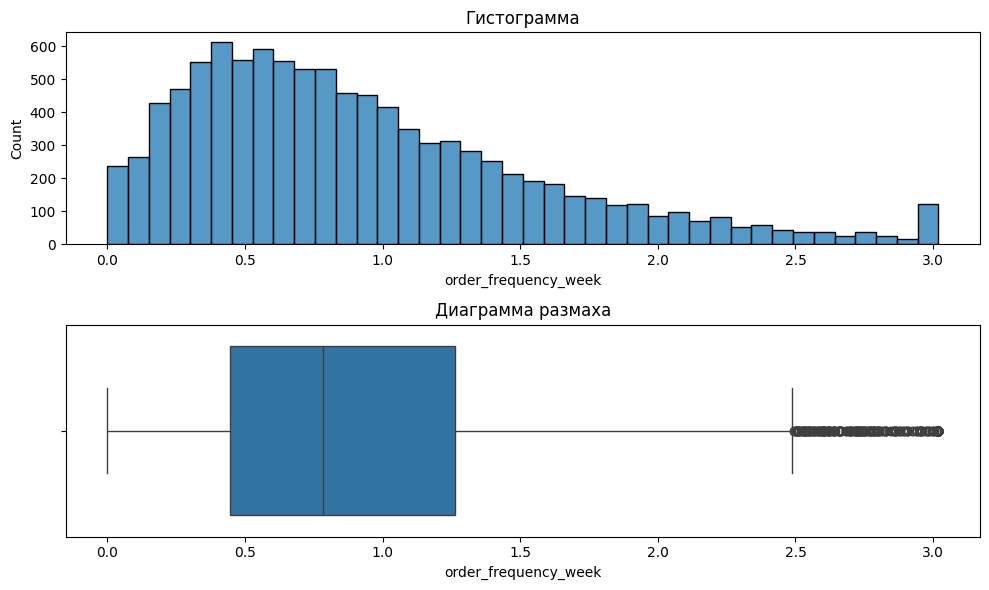

In [38]:
# Функция вывода гистограммы и диаграммы размаха
def show_diagrams(df_, col_):
    fig, axes = plt.subplots(2, 1, figsize=(10, 6)) # 2 строки, 1 столбец

    # Построение гистограммы на первом под-графике
    sns.histplot(ax=axes[0], data=df_, x=col_)
    axes[0].set_title('Гистограмма')

    # Построение диаграммы размаха на втором под-графике
    sns.boxplot(ax=axes[1], data=df_, x=col_)
    axes[1].set_title('Диаграмма размаха')

    # Автоматически настраиваем расположение графиков, чтобы избежать наложения
    plt.tight_layout()
    plt.show()
    
show_diagrams(analiz_df, 'order_frequency_week')

Как видно из диаграмм, распределение значений в колонке далеко от нормального и скошено вправо. Есть достаточно большое значение выбросов. Так как предполагамые признаки для модели отражены в колонках в разных единицах измерения, то неизбежно понадобится масшабирование. Для данной колонки из-за большого количества выбросов лучше рекомендвать масштабирование стандартизацией.

Перейдем к следующей колонке `avg_order_value` (средний чек, в рублях). Статистические показатели распределения по колонке:

In [39]:
analiz_df['avg_order_value'].describe()

count    9867.000000
mean     1063.741207
std       707.713396
min       -32.075932
25%       552.898663
50%       898.643524
75%      1406.332153
max      5901.965278
Name: avg_order_value, dtype: float64

Опять наблюдаем отрицательные значения, близкие к нулю там, где их не должно быть. Видимо, при расчете среднего чека в данные попали возвраты. Избавляемся от отрицательных значений, как и в предыущей колонке:

In [40]:
analiz_df.loc[analiz_df['avg_order_value'] < 0, 'avg_order_value'] = 0

Так же, как и в случае предыдущей колонки, максимальное значение сильно превосходит значение 75-ого перцентиля. Посмотрим, что будет для 95-ого и 99-ого перцентиля:

In [41]:
analiz_df['avg_order_value'].quantile([.95,.99])

0.95    2414.901278
0.99    3459.724876
Name: avg_order_value, dtype: float64

Значение в колонке к 95-ому и 99-ому перцентилю резко растет, но все равно примерно в полтора раза меньше максимального значения. Поэтому можно поступить так же, как и для предыущей колонки: для одного процента данных установить значение в ячейках колонки равным значению 99-ого перцентиля:


In [42]:
perc99 = analiz_df['avg_order_value'].quantile(.99)
analiz_df.loc[analiz_df['avg_order_value'] > perc99 , 'avg_order_value'] = perc99

Перейдем к гистограмме и диаграмме размаха для колонки:

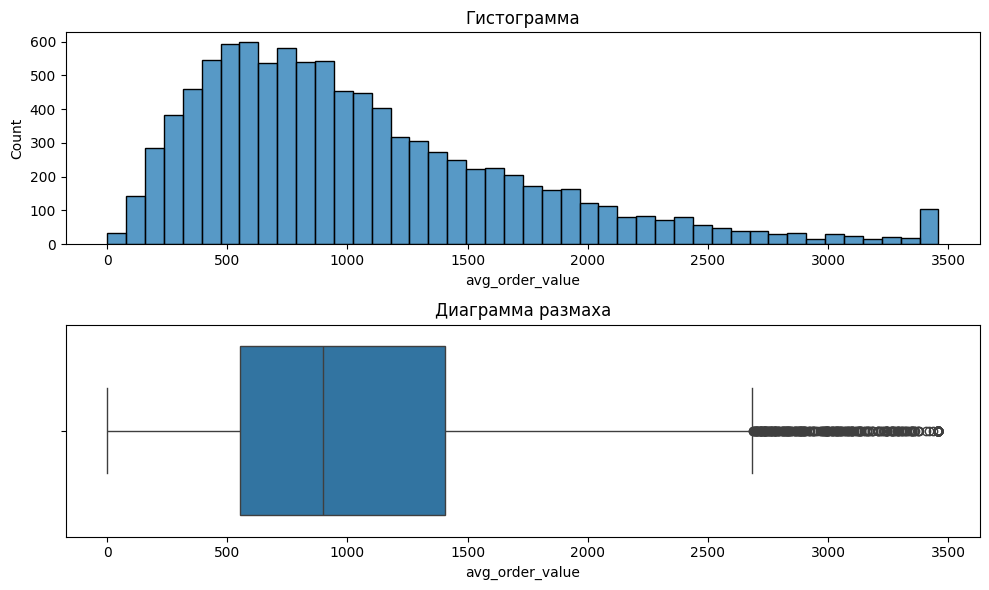

In [43]:
show_diagrams(analiz_df, 'avg_order_value')

Диаграммы похожи на соответствующие диаграммы для предыдушей колонки. Только масштаб значений другой (рубли все-таки, а не количество). Но с этим нам в будущем поможет масштабирование при помощи стандартизации.

Переходим к следующей колонке. Это - `total_spent_last_week` (сумма заказов за последнюю неделю). Начнем как всегда со статистических показателей распределения по колонке:

In [44]:
analiz_df['total_spent_last_week'].describe()

count    9506.000000
mean      413.004760
std       445.634902
min     -2290.559468
25%       136.565833
50%       288.277327
75%       549.699420
max      8615.988952
Name: total_spent_last_week, dtype: float64

Здесь подозрения вызывают как отрицательное минимальное значение, так и непомерно большое максимальное значение. Отрицательных значений, конечно, быть не должно, однако, надо посмотреть на масштаб ошибки - на количество отрицательных значений:

In [45]:
neg_count = analiz_df[analiz_df['total_spent_last_week'] < 0]['total_spent_last_week'].count()
print(f'Отрицательных значений: {neg_count}. Доля от общего количества: {neg_count/analiz_df.shape[0]:.2%}')

Отрицательных значений: 171. Доля от общего количества: 1.64%


Отрицательные значения, видимо появились из-за возвратов от покупок прошлых периодов. Доля отрицательных значений чуть больше полутора процентов, поэтому их можно безболезненно приравнять к нулю:

In [46]:
analiz_df.loc[analiz_df['total_spent_last_week'] < 0, 'total_spent_last_week'] = 0

Теперь рассмотрим выбросы в положительную сторону так же, как мы это делали для предыдущих колонок. Старшие перцентили:

In [47]:
analiz_df['total_spent_last_week'].quantile([.95,.99])

0.95    1220.462601
0.99    2053.692886
Name: total_spent_last_week, dtype: float64

Явно, как и для двух предыдущих случаев, можно аналогично обработать один процент наибольших выбросов:

In [48]:
perc99 = analiz_df['total_spent_last_week'].quantile(.99)
analiz_df.loc[analiz_df['total_spent_last_week'] > perc99 , 'total_spent_last_week'] = perc99

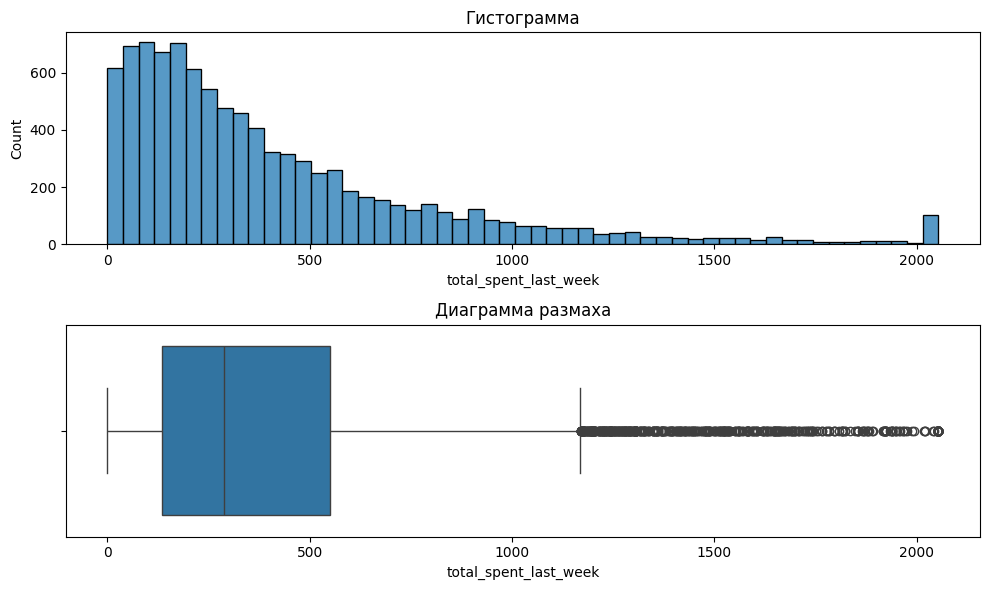

In [49]:
show_diagrams(analiz_df, 'total_spent_last_week')

Гистограмма более скошена, чем в предыдущих случаях, однако похожа. Есть схожесть и в обилии положительных выбросов. Масштаб значений похож на предыдущую колонку, что неудивительно: ведь здесь тоже рубли.

Следующая колонка - это `discount_usage_rate` (доля заказов со скидкой за последний месяц). Статистические параметры колонки:

In [50]:
analiz_df['discount_usage_rate'].describe()

count    10053.000000
mean         0.284446
std          0.158735
min          0.002162
25%          0.159884
50%          0.264583
75%          0.387056
max          0.887301
Name: discount_usage_rate, dtype: float64

Очень похоже на классическое нормальное распределение. Поэтому перейдем сразу к диаграммам:

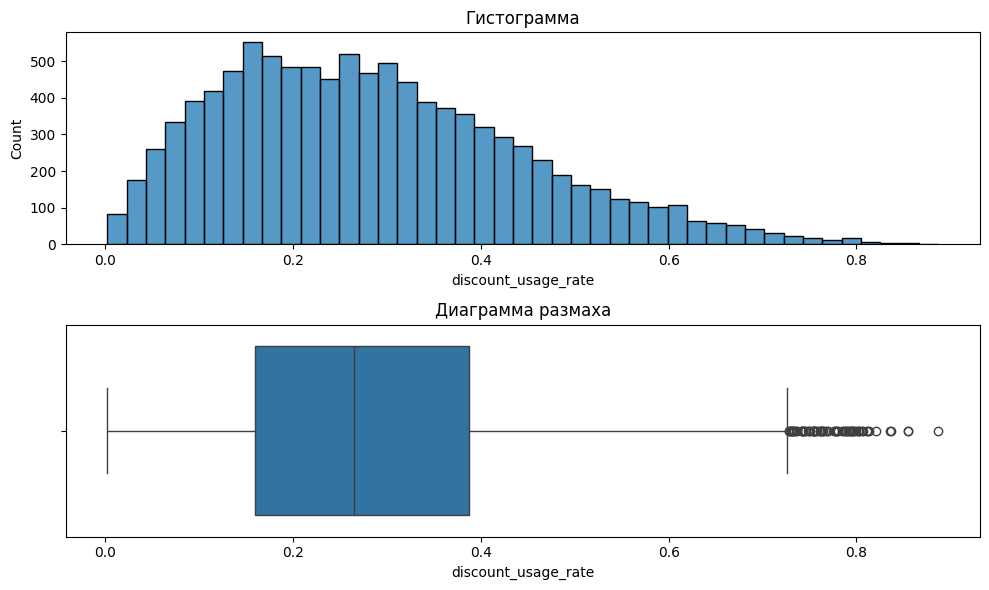

In [51]:
show_diagrams(analiz_df, 'discount_usage_rate')

Распределение немного скошено вправо, однако, даже максимальное значение не превышает единицу, поэтому нельзя уличить распределение в ошибочных выбросах. Видимо, в этом случае нужно все оставить, как есть.

Переходим к следующей колонке - `app_opens_per_week` (сколько раз за неделю пользователь в среднем открывал приложение доставки кофе). Итак, статистические параметры распределения:

In [52]:
analiz_df['app_opens_per_week'].describe()

count    9554.000000
mean       11.330895
std        14.528887
min         0.000000
25%         6.313628
50%         9.228383
75%        12.726649
max       224.587876
Name: app_opens_per_week, dtype: float64

К счастью отрицательных значений нет. Однако, максимальное значение на порядок превышает среднее значение. Наряду с 95-ым и 99 перцентилем посмотрим еще 98-ой перцентиль:

In [53]:
analiz_df['app_opens_per_week'].quantile([.95,.98,.99])

0.95    20.694326
0.98    29.576639
0.99    84.424491
Name: app_opens_per_week, dtype: float64

Интересным является то, что, если разница между 95-ым и 98-ым перцентилем составляет всего примерно 9 единиц, то значение для 99-перцентиля уже больше примерно чем в полтора раза. Поэтому в данно случае неприемлемыми выбросами лучше считать 2% значений:

In [54]:
perc98 = analiz_df['app_opens_per_week'].quantile(.98)
analiz_df.loc[analiz_df['app_opens_per_week'] > perc98 , 'app_opens_per_week'] = perc98

Смотрим диаграммы распределения:

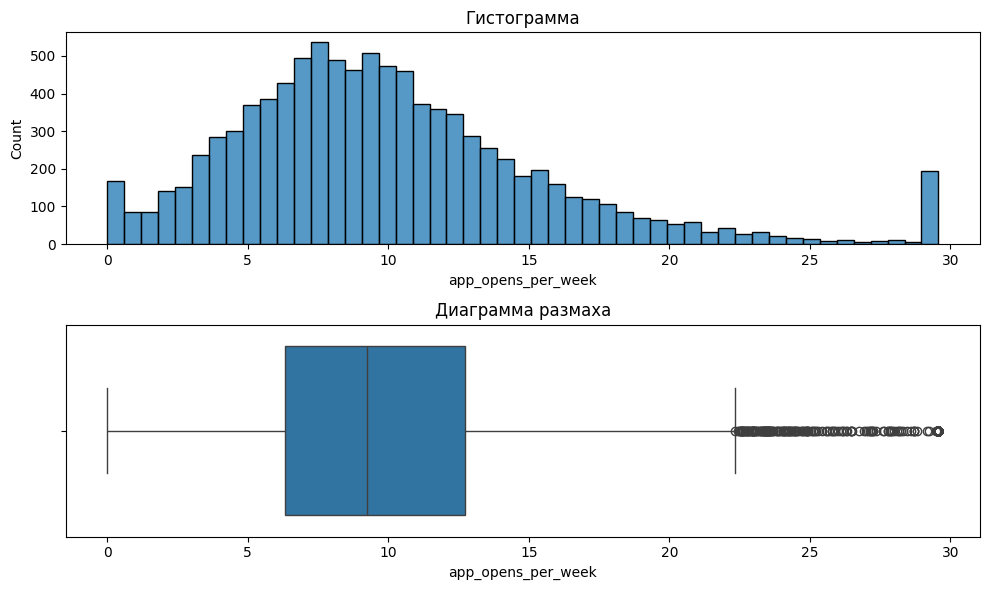

In [55]:
show_diagrams(analiz_df, 'app_opens_per_week')

После обработки выбросов их вид напоминает гистограммы предыдущей колонки. Значит работать с текущей колонкой можно так же.

Переходим к статистическим параметрам распределения следующей колонки `review_rating_last_10`:

In [56]:
analiz_df['review_rating_last_10'].describe()

count    9757.000000
mean        4.206709
std         0.782212
min         1.415526
25%         3.675543
50%         4.203555
75%         4.717292
max         7.384425
Name: review_rating_last_10, dtype: float64

Здесь среднее значение практически совпадает с медианным (50-ый перценталь), что говорит о нормальном распределении. Взглянем на диаграммы:

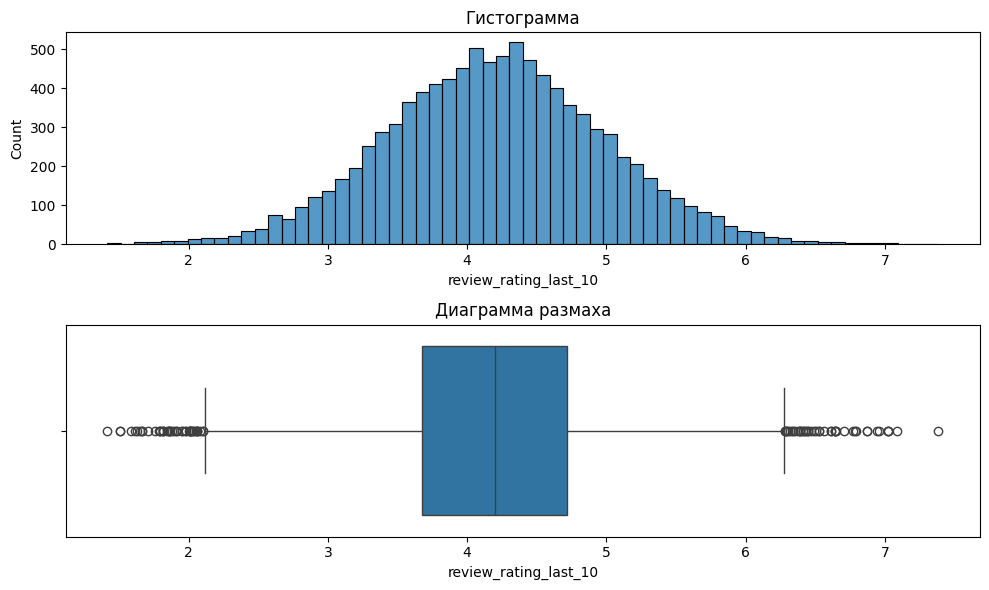

In [57]:
show_diagrams(analiz_df, 'review_rating_last_10')

Здесь мы имеем дело с практически идеальным нормальным распределением. Выбросы есть, но они тоже симметричны и не особенно велики, поэтому по поводу них ничего предпринимать не будем.

Для следующей колонки `app_crashes_last_month` ( сколько раз приложение зависало за последний месяц) начнем с гистограммы:

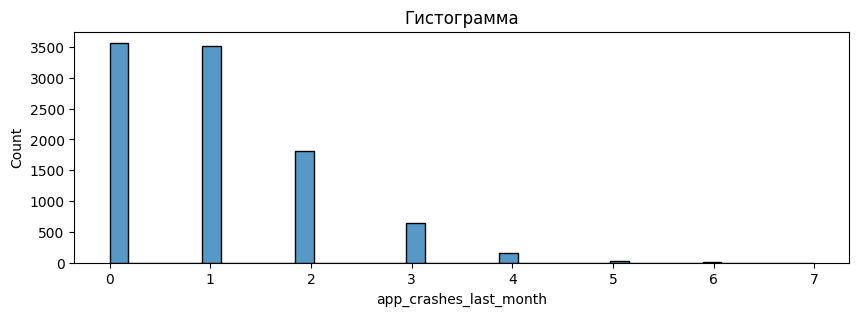

In [58]:
plt.figure(figsize=(10, 3))

# Построение гистограммы на первом под-графике
sns.histplot(data=analiz_df, x='app_crashes_last_month')
plt.title('Гистограмма')

plt.show()

Судя по гистрограмме колонка хоть и является числовой, но вместе с тем и дискретной. Поэтому с ней будем работать как с категориальной колонкой, но без кодирования, так как данные и так уже числовые. Пустые значения тоже будем заполнять как для категориальных колонок.

К дискретным можно также отнести колонки `days_since_last_order` и `days_since_last_promo`. Достаточно посмотреть на их уникальные значения: 

In [59]:
analiz_df['days_since_last_order'].unique()

array([ 0.,  2., 11.,  3.,  5.,  9., 19., nan, 14.,  6.,  4.,  1.,  8.,
       10.,  7., 15., 12., 16., 18., 17., 20., 13., 27., 24., 21., 22.,
       28., 25., 30., 23., 32., 38., 26., 37., 29., 35., 33., 40., 34.,
       36.])

In [60]:
analiz_df['days_since_last_promo'].unique()

array([  6.,  16.,  11.,   3.,  14.,  17.,   9.,  12.,   5.,   1.,  26.,
        69.,   4.,  nan,  15.,  33.,  46.,  56.,   0.,  36.,   7.,  29.,
         2.,  21.,  31.,  23.,  43.,  41.,  32.,  24.,  20.,  34.,  22.,
        67.,   8.,  19.,  37.,  27.,  77.,  35.,  13.,  49., 101., 105.,
        28.,  61.,  59.,  87.,  30.,  10.,  18.,  25.,  40.,  44.,  90.,
        38.,  51.,  75.,  53.,  62.,  66.,  85.,  39.,  42.,  68.,  52.,
        50.,  64.,  48.,  45.,  63.,  79.,  84.,  80.,  65.,  55.,  58.,
        94.,  54.,  60.,  47.,  70.,  95.,  96.,  57.,  88.,  71., 111.,
        72.,  81.,  73.,  89., 120.,  86.,  97., 140.,  83., 112.,  98.,
       115.,  74., 131.,  78.,  76., 100.,  99., 108.])

Колонки `notifications_enabled`, `seasonal_menu_tried`, `coffee_preference_change` вообще являются бинарными:

In [61]:
analiz_df['notifications_enabled'].unique()

array([ 1.,  0., nan])

In [62]:
analiz_df['seasonal_menu_tried'].unique()

array([nan,  1.,  0.])

In [63]:
analiz_df['coffee_preference_change'].unique()

array([ 0.,  1., nan])

Таким образом, последние пять колонок можно отнести к категориальным, причем без необходимости кодирования. Добавим их в именованный список:

In [64]:
discrete_col = ['app_crashes_last_month', 
             'days_since_last_order', 
             'days_since_last_promo', 
             'notifications_enabled', 
             'seasonal_menu_tried',
             'coffee_preference_change']

Итак, во время первичного анализа данных была проделана следуюшая работа:
- Дано краткое описание данных: их период агрегации, формат и структура.
- Описна целевая переменная. При этом найден очень большой дисбаланс в классах целевой переменной. Всего 6% элементов относятся к положительному классу.
- Описаны потенциальные признаки модели (колонки считанного из файла датафрейма).
- Из числа признаков исключены колонки `user_id` и `seasons`. Вторая колонка была исключена из-за смыслового несоответствия периода агрегации и содержимого колонки. Ведь данные были агрегированы за последние 4 недели, что предполагает присутствие в данных максимально двух сезонов года, если данные собирались на стыке двух месяцев, находящихся на стыке двух сезонов. В данных же присутствовали 4 сезона.
- Во время описания колонок загруженного датасета были выявлены пары потенциальных признаков в одинаковым смыслом, но с разными периодами агрегации, методом расчета усреднения или количеством усредненных данных. Для избежания колинеарности из числа потенциальных признаков модели из каждой пары были исключены признаки с меньшим коэффициентом корреляции с целевой переменной.
- Создан датасет, содержащий оставшиеся после отсеивания признаки и целевую переменную.
- Колонки вновь созданного датасета были проанализированы на предмет заполнения пропусков, метода категоризции для текстовых колонок, методов работы с выбросами и масштабированием для непрерывных числовых колонок.

*[Содержание](#sod)*

<a id='obr'></a>
## Этап 3. Предобработка данных

1. Разделите данные в пропорции 80 к 20. 20% данных отложите для теста. Остальные используйте для обучения и кросс-валидации модели.

2. Предобработайте данные. Используйте информацию о пропусках и категориальных признаках только из обучающей выборки.

   - Создайте пайплайн, который обработает пропуски и выбросы.

   - Создайте пайплайн, который обработает категориальные признаки.

   - Создайте пайплайн, который обработает числовые признаки: проведёт масштабирование и нормализацию.



Перед отделением данных для теста разделим датафрейм на признаки и вектор целевой переменной:

In [65]:
# Разделяем признаки и целевую переменную
X = df.drop(columns=['churn'])
y = df['churn']

Теперь следует отделить выборку тестовых данных, при этом не забывая, что нужно сохранить пропорцию классов целевой переменной, так как в их распределении есть очень большой дисбаланс:


In [66]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Размер обучающей выборки: {X_train_val.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Доля положительного класса в train: {y_train_val.mean():.2%}")
print(f"Доля положительного класса в test: {y_test.mean():.2%}")

Размер обучающей выборки: (8360, 20)
Размер тестовой выборки: (2090, 20)
Доля положительного класса в train: 6.02%
Доля положительного класса в test: 6.03%


Доля положительного класса в обеих выборках составляет 6%, что соответствую состоянию в исходном загруженном датафрейме. Значит, разделение произошло правильно.

Теперь займемся предварительной обработкой данных. Порядок обработки будет зависеть от типа колонок. Поэтому воспользуемся уже произошедшим разделением колонок на категориальные и числовые:


In [67]:
print('Категориальные:\n----------------')
print(f'{cat_col}\n')
print('Числовые:\n----------------')
print(num_col)

Категориальные:
----------------
['last_coffee_type', 'preferred_roast', 'milk_preference', 'coffee_bean_origin', 'last_drink_size', 'subscription_status', 'phone_type', 'geo_location']

Числовые:
----------------
['days_since_last_order', 'order_frequency_week', 'avg_order_value', 'total_spent_last_week', 'discount_usage_rate', 'seasonal_menu_tried', 'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10', 'app_crashes_last_month', 'days_since_last_promo', 'coffee_preference_change']


Здесь есть одна проблемка: как было выяснено в предыдущем этапе пять колонок хоть и являются числовыми, но их нужно перенести в категориальные.

In [68]:
cat_col = cat_col + discrete_col
num_col = [item for item in num_col if item not in discrete_col]
print('Категориальные:\n----------------')
print(f'{cat_col}\n')
print('Числовые:\n----------------')
print(num_col)

Категориальные:
----------------
['last_coffee_type', 'preferred_roast', 'milk_preference', 'coffee_bean_origin', 'last_drink_size', 'subscription_status', 'phone_type', 'geo_location', 'app_crashes_last_month', 'days_since_last_order', 'days_since_last_promo', 'notifications_enabled', 'seasonal_menu_tried', 'coffee_preference_change']

Числовые:
----------------
['order_frequency_week', 'avg_order_value', 'total_spent_last_week', 'discount_usage_rate', 'app_opens_per_week', 'review_rating_last_10']


Теперь все правильно. Переходим к работе с категориальными колонками. Первое, что надо сделать для них - это заполнить пропуски. Для категориальных признаков пустые значения будут заполняться наиболее частыми в каждом отдельном столбце. Т.е. при заполнении воспользуемся стратегией заполнения `most_frequent`.

Для осуществления этого создадим конвейер работы с категориальными данными, куда включим шаг обработки пропусков:

In [69]:
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

Теперь создадим общий препроцессор обработки данных, который будет подавать на вход категориального конвейера только категориальные колонки:

In [70]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_transformer, cat_col)
    ])

Проверим, что получилось:

In [71]:
transform_np = preprocessor.fit_transform(X_train_val)
transform_df = pd.DataFrame(transform_np, columns=cat_col)
transform_df.isna().sum()

last_coffee_type            0
preferred_roast             0
milk_preference             0
coffee_bean_origin          0
last_drink_size             0
subscription_status         0
phone_type                  0
geo_location                0
app_crashes_last_month      0
days_since_last_order       0
days_since_last_promo       0
notifications_enabled       0
seasonal_menu_tried         0
coffee_preference_change    0
dtype: int64

Пропусков в обработанных категориальных колонках нет. Следующим шагом, который нужно сделать для категориальных колонок - это кодировка текстовых колонок. Здесь способ обработки категориальных колонок разделяется. Для колноки `app_crashes_last_month` вообще не нужна кодировка, она и так числовая. В колонке `geo_location` много уникальных значений, поэтому ее будем кодировать методом `TargetEncoder`. В остальных колонках количество уникальных значений невелико, поэтому для них воспользуемся методом `OneHotEncoder`.

Перед кодированием нужно решить еще одну проблемку. Класс `TargetEncoder` обычно работает с датафреймами, поэтому мы должны из обработанных ранее данных в виде np массива получить датафрейм и индексы привести в соответствие первоначальным датафреймом, поданным на вход, иначе кодирование не состоится. Для этого создадим функцию и включим ее в ранее созданный категориальный конвейер.

In [72]:
# Функция переиндексации по первоначальным данным
def reset_df_index(X_, X_orig, cols_all):
    X_df = pd.DataFrame(X_, columns=cols_all)
    X_df = X_df.apply(pd.to_numeric, errors="ignore")
    X_df['idx'] = X_orig.reset_index()['index']
    X_idx = X_df.set_index('idx')
    return X_idx

# Конвейер для категориальных данных
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('reset_df_index', FunctionTransformer(reset_df_index, validate=False))
])

# Общий препроцессор обработки колонок
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_transformer, cat_col)
    ])

Теперь можно приступать к кодированию. Так как методы кодирования для колонок разные, то создадим ещё один препроцессор обработки колонок уже для нашего конвейера категориальных данных. В нем будет три трансформации: для колонок с кодированием по методу `OneHotEncoder`, для геоколонки `geo_location` с кодирование по методу `TargetEncoder` и для числовой колонки `app_crashes_last_month`, которой колирование вообще без надобности. Потом наш местный препроцессор добавим в конвейер последним шагом. Все описанное показано ниже:
<a id='cat_trans'></a>

In [73]:
onehot_col = [item for item in cat_col if item not in discrete_col]
onehot_col.remove('geo_location')
# Препроцессор для кодирования категориальных данных
cat_preproc = ColumnTransformer(
    transformers=[
        ('incode_onehot', OneHotEncoder(handle_unknown='ignore'), onehot_col),
        ('incode_target', TargetEncoder(), ['geo_location']),
        ('incode_no', SimpleImputer(missing_values=np.nan, strategy='constant',fill_value=0), discrete_col)
    ])

# Конвейер для предобработки категориальных данных
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('reset_df_index', FunctionTransformer(reset_df_index, validate=False)),
    ('cat_preproc', cat_preproc)
])

# Общий препроцессор
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_transformer, cat_col)
    ])

Проверим, что получилось:

In [74]:
# Задаем параметры для функции переиндексации
preprocessor.transformers[0][1].set_params(reset_df_index__kw_args={'X_orig': X_train_val, 'cols_all':cat_col})
transform_np = preprocessor.fit_transform(X_train_val, y_train_val)
transform_np[200]

C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")


array([ 0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
        1.        ,  0.        ,  0.        ,  0.        ,  1.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        1.        ,  0.        ,  0.        ,  0.        ,  1.        ,
        0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
        1.        ,  0.        ,  0.        ,  0.04678826,  1.        ,
        6.        , 14.        ,  1.        ,  1.        ,  0.        ])

Данные вернулись в виде массива, а не датафрейма. Чтобы получить более полное представление преобразуем его в датафрейм. Для этого сначала сгенерируем колонки датафрейма для просмотра, потом проанализируем.

In [75]:
# Формирование списка колонок после кодирования 
cat_mod_col = []
for col in onehot_col:
    n_uniq = X_train_val[col].nunique()
    for i in range(n_uniq):
        cat_mod_col.append(col+'_'+str(i+1))
        
# Добавляем колонки с другим кодированием и без оного
cat_mod_col.append('geo_location')
cat_mod_col = cat_mod_col + discrete_col

# Получаем датафрейм
transform_df = pd.DataFrame(transform_np, columns=cat_mod_col)
# Преобразуем все что можно в числа
transform_df = transform_df.apply(pd.to_numeric, errors="ignore")
# ... и смотрим
transform_df.info()
transform_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8360 entries, 0 to 8359
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   last_coffee_type_1        8360 non-null   float64
 1   last_coffee_type_2        8360 non-null   float64
 2   last_coffee_type_3        8360 non-null   float64
 3   preferred_roast_1         8360 non-null   float64
 4   preferred_roast_2         8360 non-null   float64
 5   preferred_roast_3         8360 non-null   float64
 6   milk_preference_1         8360 non-null   float64
 7   milk_preference_2         8360 non-null   float64
 8   milk_preference_3         8360 non-null   float64
 9   milk_preference_4         8360 non-null   float64
 10  milk_preference_5         8360 non-null   float64
 11  milk_preference_6         8360 non-null   float64
 12  coffee_bean_origin_1      8360 non-null   float64
 13  coffee_bean_origin_2      8360 non-null   float64
 14  coffee_b

C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3125078188.py:15: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  transform_df = transform_df.apply(pd.to_numeric, errors="ignore")


,last_coffee_type_1,last_coffee_type_2,last_coffee_type_3,preferred_roast_1,preferred_roast_2,preferred_roast_3,milk_preference_1,milk_preference_2,milk_preference_3,milk_preference_4,...,phone_type_1,phone_type_2,phone_type_3,geo_location,app_crashes_last_month,days_since_last_order,days_since_last_promo,notifications_enabled,seasonal_menu_tried,coffee_preference_change
0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.127772,0.0,0.0,5.0,1.0,1.0,1.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.069484,0.0,5.0,2.0,1.0,1.0,0.0
2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.023088,0.0,0.0,9.0,1.0,1.0,1.0
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.069934,0.0,0.0,2.0,1.0,1.0,0.0
4,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.033219,0.0,2.0,43.0,1.0,1.0,0.0


Все колонки стали числовыми и соответствуют ожиданиям. Категориальные данные к моделированию готовы.

Отложим в сторону категориальные данные и займемся числовыми. Начнем с заполнения пропусков. Тут метод заполнения один - по среднему значению. Создаем конвейер для числовых данных, добавляем в него шаг с заполнением пропусков и включаем числовой конвейер в общий препроцессор обработки колонок:


In [76]:
# Конвейер для числовых данных
num_transformer = Pipeline(steps=[
    ('imputer_num', SimpleImputer(strategy='mean'))
])

# Общий препроцессор обработки колонок
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_col)
    ])

Пробуем получившийся инструмент:

In [77]:
transform_np = preprocessor.fit_transform(X_train_val)
transform_df = pd.DataFrame(transform_np, columns=num_col)
transform_df.isna().sum()

order_frequency_week     0
avg_order_value          0
total_spent_last_week    0
discount_usage_rate      0
app_opens_per_week       0
review_rating_last_10    0
dtype: int64

Пропуски в числовых колонках пропали. Теперь займемся выбросами в них. Исходя из первичного анализа, не нужно проверять выбросы в колонках `discount_usage_rate` и `review_rating_last_10`. В остальных колонках нужно значния большие величины для определенного перцинтиля приравнять к значению этого перцентиля и/или проверить наличие отрицательных значений и приравнять их к нулю. Для выполнения этих действий создадим функцию, которой воспользуемся в специальном препроцессоре для количественных колонок, который будет делить колонки на два типа: с необходимостью обрабатывать выбросы и без оной. Подобным мы уже занимались для категориальных колонок. 

In [78]:
# Функция для работы с выбросами числовых данных
def remove_excess(X_, perc98, exc_cl):
    X_df = pd.DataFrame(X_, columns=exc_cl)
    X_df = X_df.apply(pd.to_numeric, errors="ignore")
    for col in exc_cl:
        X_df.loc[X_df[col] < 0, col] = 0
        perc98 = X_df[col].quantile(.98)
        X_df.loc[X_df[col] > perc98 , col] = perc98
    return X_df.to_numpy()

# Пустая функция: что поступило на вход, выдаем на выход
def pass_excess(X_):
    return X_


# Колонки с выбросами
exc_col = num_col.copy()
exc_col.remove('discount_usage_rate')
exc_col.remove('review_rating_last_10')
exc_no_col = ['discount_usage_rate', 'review_rating_last_10']
# Препроцессор для работы с выбросами числовых данных
num_preproc = ColumnTransformer(
    transformers=[
        ('excess_yes', FunctionTransformer(remove_excess, validate=False, kw_args={'perc98': 0.98, 'exc_cl': exc_col}), exc_col),
        ('excess_no', FunctionTransformer(pass_excess, validate=False), exc_no_col),
    ])

# Конвейер для предобработки числовых данных
num_transformer = Pipeline(steps=[
    ('imputer_num', SimpleImputer(strategy='mean')),
    # Для работы препроцессора обработки выбросов ему на вход нужно подать датафрейм.
    # Сделаем это при помощи функции переиндексации - она же выдает на выходе датафрейм
    ('reset_df_index', FunctionTransformer(reset_df_index, validate=False)),
    ('num_preproc', num_preproc)
])

# Общий препроцессор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_col)
    ])

# Названия колонок после обработки выбросов (порядок важен(!))
num_mod_col = exc_col + ['discount_usage_rate', 'review_rating_last_10'] 

Сначала проверим количество отрицательных значений:

In [79]:
preprocessor.transformers[0][1].set_params(reset_df_index__kw_args={'X_orig': X_train_val, 'cols_all':num_col})
transform_np = preprocessor.fit_transform(X_train_val)
transform_df = pd.DataFrame(transform_np, columns=num_mod_col)

# Проверяем отрицательные значения
print('Количество отрицательных значений:')
print('----------------------------------')
for col in exc_col:
    neg_count = transform_df[transform_df[col] < 0][col].count()
    print(f'Колонка: {col} - Значений: {neg_count}')

Количество отрицательных значений:
----------------------------------
Колонка: order_frequency_week - Значений: 0
Колонка: avg_order_value - Значений: 0
Колонка: total_spent_last_week - Значений: 0
Колонка: app_opens_per_week - Значений: 0


C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\287454607.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")


Отрицательных значений нет. Хорошо. Теперь посмотрим диаграммы распределения одной из колонок с выбросами в положительную сторону:

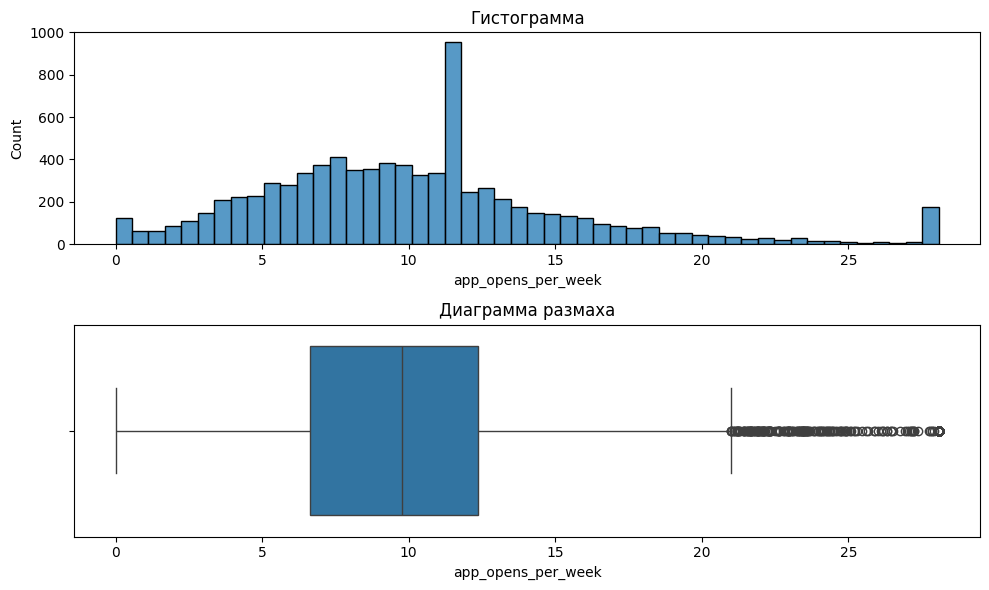

In [80]:
show_diagrams(transform_df, 'app_opens_per_week')

Диаграммы похожи на те, что мы видели при проведении первичного анализа. Высокий столбец на диаграмме связан с заполнением пустых значний средним по столбцу. значит, и с положительными выбросами все нормально.

Осталось масштабировать все столбцы методом стандартизации, как мы решили сделать во время первичного анализа. Применим одинаковый метод для всех числовых колонок. Для этого дополним конвейер обработки числовых данных еще одним шагом с функцией масштабирования:<a id='num_trans'></a> 

In [81]:
# Препроцессор для работы с выбросами числовых данных
exc_no_col = ['discount_usage_rate', 'review_rating_last_10']
num_preproc = ColumnTransformer(
    transformers=[
        ('excess_yes', FunctionTransformer(remove_excess, validate=False, kw_args={'perc98': 0.98, 'exc_cl': exc_col}), exc_col),
        ('excess_no', FunctionTransformer(pass_excess, validate=False), exc_no_col),
    ])

# Конвейер для предобработки числовых данных
num_transformer = Pipeline(steps=[
    ('imputer_num', SimpleImputer(strategy='mean')),
    # Для работы препроцессора обработки выбросов ему на вход нужно подать датафрейм.
    # Сделаем это при помощи функции переиндексации - она же выдает на выходе датафрейм
    ('reset_df_index', FunctionTransformer(reset_df_index, validate=False)),
    ('num_preproc', num_preproc),
    ('num_scaler', StandardScaler()),
])

# Общий препроцессор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_col)
    ])

Для проверки посмотрим статистические диаграммы распределения для двух колонок, у которых значения доходили до сотни тысяч единиц.

C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\287454607.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")


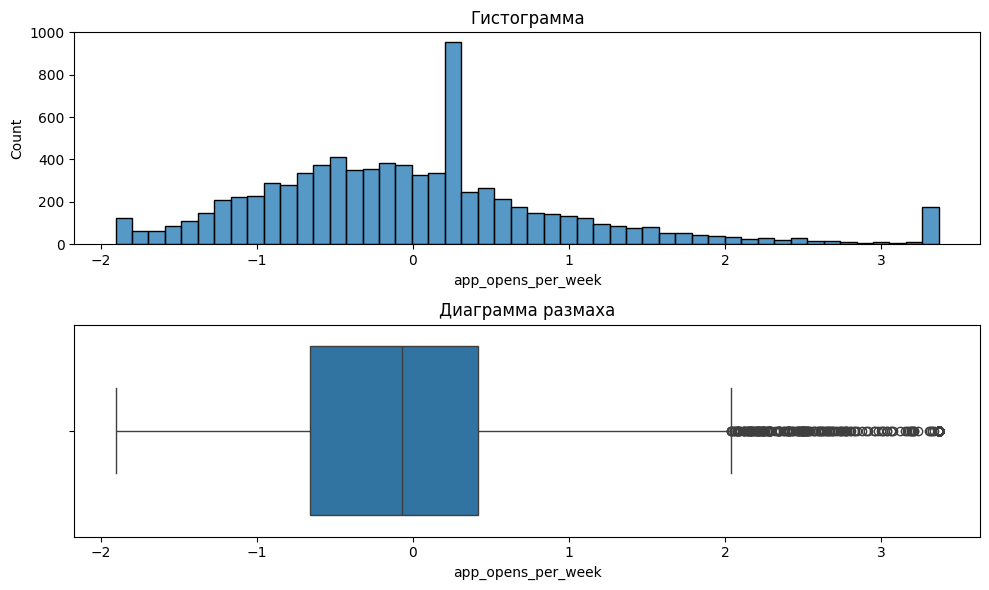

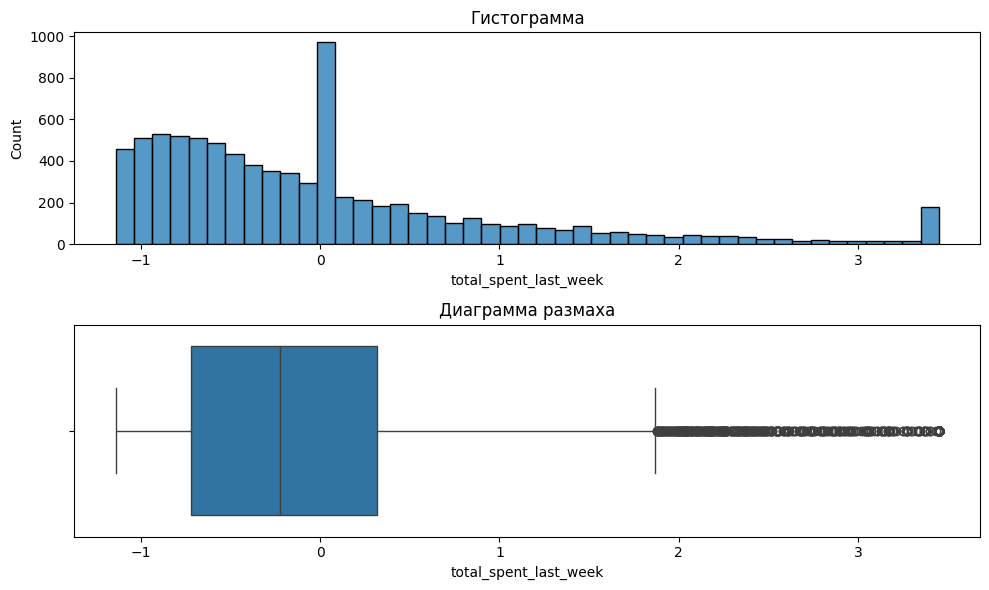

In [82]:
preprocessor.transformers[0][1].set_params(reset_df_index__kw_args={'X_orig': X_train_val, 'cols_all':num_col})
transform_np = preprocessor.fit_transform(X_train_val)
transform_df = pd.DataFrame(transform_np, columns=num_mod_col)
show_diagrams(transform_df, 'app_opens_per_week')
show_diagrams(transform_df, 'total_spent_last_week')

Диаграммы показывают, что для обеих колонок диапазон значений характерен для масшабирования методом стандартизации.

Осталось объединить обработку категориальных и числовых данных. Для этого достаточно добавить одну строчку в общий препроцессор обработки данных.


In [83]:
# Общий препроцессор
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_transformer, cat_col), # обработка категориальных данных
        ('num', num_transformer, num_col)  # обработка числовых данных
    ])

Для того, чтобы посмотреть окончательные варианты варианты конвейеров достаточно перейти по ссылкам:
- *[cat_transformer](#cat_trans)* - конвейер для обработки категориальных данных
- *[num_transformer](#num_trans)* - конвеер для обработки числовых данных

Перед проверкой окончательного варианта общего препроцессора обработки колонок необходимо не забыть задать параметры пользовательских функций:

In [84]:
# Задаем параметры для функции переиндексации для категориальных данных
preprocessor.transformers[0][1].set_params(reset_df_index__kw_args={'X_orig': X_train_val, 'cols_all':cat_col})
# Задаем параметры для функции переиндексации и создания датафрейма для числовых данных
preprocessor.transformers[1][1].set_params(reset_df_index__kw_args={'X_orig': X_train_val, 'cols_all':num_col})
transform_np = preprocessor.fit_transform(X_train_val, y_train_val)
transform_df = pd.DataFrame(transform_np, columns= cat_mod_col + num_mod_col)
transform_df.info()
transform_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8360 entries, 0 to 8359
Data columns (total 41 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   last_coffee_type_1        8360 non-null   float64
 1   last_coffee_type_2        8360 non-null   float64
 2   last_coffee_type_3        8360 non-null   float64
 3   preferred_roast_1         8360 non-null   float64
 4   preferred_roast_2         8360 non-null   float64
 5   preferred_roast_3         8360 non-null   float64
 6   milk_preference_1         8360 non-null   float64
 7   milk_preference_2         8360 non-null   float64
 8   milk_preference_3         8360 non-null   float64
 9   milk_preference_4         8360 non-null   float64
 10  milk_preference_5         8360 non-null   float64
 11  milk_preference_6         8360 non-null   float64
 12  coffee_bean_origin_1      8360 non-null   float64
 13  coffee_bean_origin_2      8360 non-null   float64
 14  coffee_b

C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\287454607.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")


,last_coffee_type_1,last_coffee_type_2,last_coffee_type_3,preferred_roast_1,preferred_roast_2,preferred_roast_3,milk_preference_1,milk_preference_2,milk_preference_3,milk_preference_4,...,days_since_last_promo,notifications_enabled,seasonal_menu_tried,coffee_preference_change,order_frequency_week,avg_order_value,total_spent_last_week,app_opens_per_week,discount_usage_rate,review_rating_last_10
0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,5.0,1.0,1.0,1.0,0.496088,-1.243300,-0.530439,1.284403,0.301801,-1.171972e-15
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,2.0,1.0,1.0,0.0,-0.345881,0.534749,-0.201795,-0.634623,-0.758603,-1.897074e-01
2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.0,1.0,1.0,1.0,0.201470,0.459019,0.216401,0.227496,-1.384516,-5.030711e-01
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,2.0,1.0,1.0,0.0,-0.252677,1.525051,1.462362,0.227496,-0.176326,5.120347e-02
4,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,43.0,1.0,1.0,0.0,-0.503712,-1.095402,0.023344,0.191243,-0.058903,-1.378997e+00


В результате получили таблицу числовых признаков, готовых для моделирования.

Таким образом, в процессе предварительной обработки данных была проделана следующая работа:
- Датафрейм был разделен на матрицу данных и вектор целевой переменной. Далее из данных была выделена тестовая часть (20%) с учетом сильной диспропроции классов целевой переменной (доля положительного класса всего около 6%).
- Был создан общий препроцессор обработки колонок, содержащий конвейеры обработки данных отдельно для категориальных и для числовых данных.
- Конвейер для категориальных данных позволяет убрать пропуски в категориальных данных, затем произвести их кодирование (перевод текстовых значений в цифру) различными методами.
- Конвейер числовых данных обеспечивает заполнение пропусков по среднему, обработку выбросов и масштабирование числовых данных методом стандартизации.
- В результате получен общий препроцессор обработки колонок, который позволяет получить признаки в числовом виде, пригодном для дальнейшего моделирования.

*[Содержание](#sod)*

<a id='edu'></a>
## Этап 4. Обучение модели

1. Обучите базовую версию модели.
   - Используйте для этого простые статистические модели.

   - Используйте кросс-валидацию для обучения модели.

2. Посчитайте метрики, поставленные в задаче. Опираясь на них, сделайте вывод о качестве модели.

В качестве базовой модели можно использовать `DummyClassifier`. Она представляет собой простейшую (dummy) модель, которая всегда предсказывает наиболее часто встречающийся класс целевой переменной. В нашем случае, когда есть большущий дисбаланс в классах целевой переменной, она гарантированно будет выдавать 0 (т.е. клиент никогда не откажется от сервиса доставки кофе).

Для обеспечения кросс-валидации будем пользоваться классом `StratifiedKFold`, который при валидации обеспечит сохранение пропроции между классами целевой переменной как в обучающей, так и в валидационной выборке.

Сделаем отдельный конвейер обработки данных, в которой объединим препроцессор предварительной обработки `preprocessor` и используемую модель `DummyClassifier`.

In [85]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)

pipeline = Pipeline(steps=[
    ('prep', preprocessor),
    ('baseline', baseline)
])

Для организации процсса автоматической кросс-валидаци и получения значений метрик воспользуемся функцией `cross_validate`. В качестве метрики будем использовать рекомендованную метрику **Precision-Recall AUC (PR AUC)**. Она фокусируется на корректном предсказании меньшего по объёму, но ключевого для задачи класса — уходящих клиентов. Итак, расчет для базовой модели показывает следующее:

In [86]:
pipeline.steps[0][1].transformers[0][1].set_params(reset_df_index__kw_args={'X_orig': X_train_val, 'cols_all':cat_col})
pipeline.steps[0][1].transformers[1][1].set_params(reset_df_index__kw_args={'X_orig': X_train_val, 'cols_all':num_col})

res = cross_validate(pipeline, X_train_val, y_train_val.to_numpy(), scoring=['average_precision'], cv=cv)

print('Значение метрики для каждого цикла валидации:')
print(res['test_average_precision'])
print('Усредненное значение метрики:')
print(f'{np.mean(res["test_average_precision"]):.7f}')

C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\287454607.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future ve

Значение метрики для каждого цикла валидации:
[0.05980861 0.05980861 0.0604067  0.0604067  0.0604067 ]
Усредненное значение метрики:
0.0601675


C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\287454607.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")


Результат соответствует базовой линии, которая в свою очередь соответстует доле положительного класса (в нашем случае 6%). Ожидаемый результат для базовой модели.

В дальнейшем нам предстоит просчитать несколько моделей, поэтому создадим функцию для расчета и помещения результатов в специальный датафрейм:


In [87]:
data = {'Модель': ['DummyClassifier'], 
        'Новые признаки': [''], 
        'Гиперпараметры': [''], 
        'PR AUC': [0.],
        'CV%': [0.]
       }
res_df = pd.DataFrame(data)
res_df

,Модель,Новые признаки,Гиперпараметры,PR AUC,CV%
0,DummyClassifier,,,0.0,0.0


В этом датафрейме результатов CV% - коэффициент вариации, показывающий относительную стабильнсть модели. Ниже приведена функция для заполнения этого датафрейма результатами расчетов для выбранной модели с настроенныйм конвейером предварительной обработки признаков:

In [88]:
# Функция расчета метрики PR AUC модели и записи ее в датафрейм результатов
# model_ - модель
# cat_trans - препроцессор обработки категориальных колонок
# num_trans - препроцессор обработки числовых колонок
# X_mod - матрица признаков
# y_mod - вектор целевой переменной
# col_cat_ - список категориальных колонок матрицы признаков
# col_num_ - список категориальных колонок матрицы признаков
# params - параметры описания модели для датафрейма результатов
# df_ - датафрейм результатов
def work_model(model_, cat_trans_, num_trans_, X_mod, y_mod, col_cat_, col_num_, params, df_):
    #print(X_mod.info())
    
    cv_ = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    prepoc_ = ColumnTransformer(
        transformers=[
            ('cat', cat_trans_, col_cat_), # обработка категориальных данных
            ('num', num_trans_, col_num_)  # обработка числовых данных
        ])
    
    pipeline = Pipeline(steps=[
        ('prep', prepoc_),
        ('model', model_)
    ])

    pipeline.steps[0][1].transformers[0][1].set_params(reset_df_index__kw_args={'X_orig': X_mod, 'cols_all':col_cat_})
    pipeline.steps[0][1].transformers[1][1].set_params(reset_df_index__kw_args={'X_orig': X_mod, 'cols_all':col_num_})
    
    res = cross_validate(pipeline, X_mod, y_mod.to_numpy(), scoring=['average_precision'], cv=cv_)

    idx = 0
    if_df = (df_['Модель'] == params[0]) & (df_['Новые признаки'] == params[1]) & (df_['Гиперпараметры'] == params[2])
    if if_df.sum() == 0:
        idx = len(df_)
    else:
        idx = df_[if_df].head(1).index[0]
    
    df_.loc[idx,'Модель'] = params[0]
    df_.loc[idx,'Новые признаки'] = params[1]
    df_.loc[idx,'Гиперпараметры'] = params[2]
    
    # Вычисляем метрики
    df_.loc[idx,'PR AUC'] = round(np.mean(res["test_average_precision"]),4)
    df_.loc[idx,'CV%'] = round(np.std(res["test_average_precision"])/np.mean(res["test_average_precision"]) * 100, 2)

Попробуем нашу функцию на базовой модели `DummyClassifier`:

In [89]:
work_model(baseline, cat_transformer, num_transformer,
           X_train_val, y_train_val, cat_col, num_col, ['DummyClassifier','',''], res_df)
res_df

C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\287454607.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future ve

,Модель,Новые признаки,Гиперпараметры,PR AUC,CV%
0,DummyClassifier,,,0.0602,0.49


Базовая модель показывает поразительно низкий результат для использумой метрики и поразительную устйчивость. Ещё бы, ведь она предсказывает в нашем случае всегда одно и то же. Теперь теперь посмотрим, какой результат покажет модель логистической регрессии `LogisticRegression`:

In [90]:
work_model(LogisticRegression(max_iter=350), cat_transformer, num_transformer,
           X_train_val, y_train_val, cat_col, num_col, ['LogisticRegression','',''], res_df)
res_df

C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\287454607.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future ve

,Модель,Новые признаки,Гиперпараметры,PR AUC,CV%
0,DummyClassifier,,,0.0602,0.49
1,LogisticRegression,,,0.6876,7.15


Модель логистической регрессии показывает потрясающий прогресс по сравнению с базовой моделью, правда в устойчивости слегка проигрыает (тяжело предсказывать не одно и то же). С другой стороны CV% этой модели ниже 10%, поэтому ее стоит признать очень стабильной моделью.

Итак в текущем пункте была проделана следующая работа:
- Создан датафрейм, в котором будут хранится результаты для различных моделей и данных для них, которые будут появляться в этой работе.
- Написана функция для расчетов с использованием кросс-валидации для различных моделей и данных к ним и для помещения результатов расчетв в ранее созданный датафрейм.
- Функция расчета опробована на базовой модели и модели логистической регрессии.

*[Содержание](#sod)*

<a id='signs'></a>
## Этап 5. Создание новых признаков

1. Добавьте новые признаки, которые могут улучшить качество модели. Опирайтесь на наработки, полученные в ходе исследовательского анализа данных, и на логику решаемой задачи.

   - Извлечение квадратного корня поможет сгладить большие значения.

   - Возведение в квадрат усилит влияние больших значений.

2. Обновите пайплайн для работы с новыми признаками, проведите повторную кросс-валидацию, сравните результаты моделей с новыми признаками и без них.

3. Интерпретируйте коэффициенты модели, а затем на их основании выявите значимые признаки и удалите лишние для модели.

Скопируем датафрейм с подобранными данными для моделирвания для создания новых признаков:

In [91]:
X1_train_val = X_train_val.copy()

<a id='add1'></a>Попробуем учшить качество модели, добавляя новые признаки. Начнем с улучшения распределения некоторых признаков. Так, диаграммы распределения до предобработки для признака `total_spent_last_week` (сумма заказов за последнюю неделю) выглядят так: 

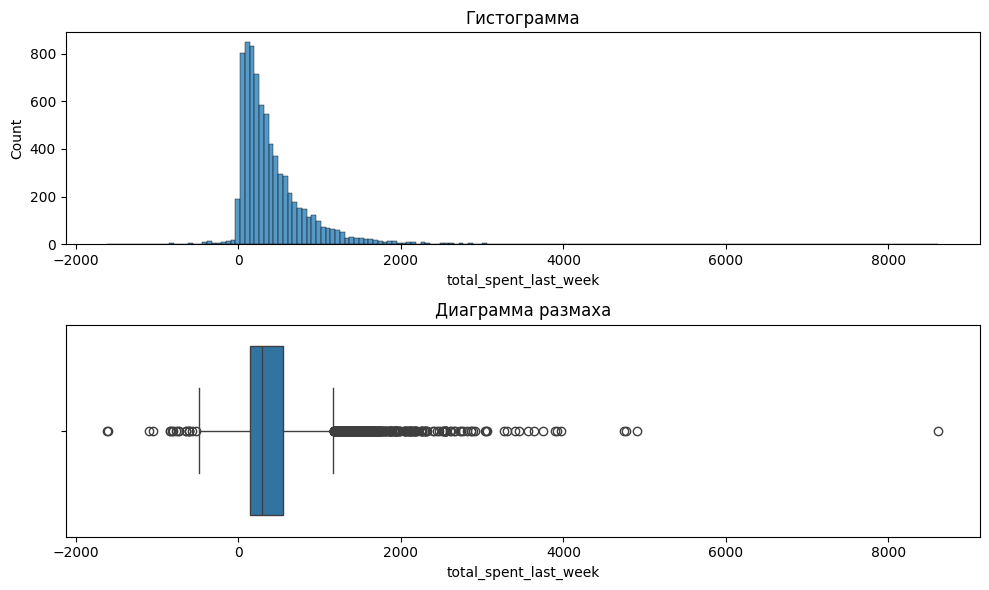

In [92]:
show_diagrams(X1_train_val, 'total_spent_last_week')

Распределение сильно скошено вправо, есть много выбросов. Для выравнивания данных воспользуемся логарифмическим преобразованием, предварительно обнулив ошибочные отрицательные выбросы и посмотрим на новое распределение:

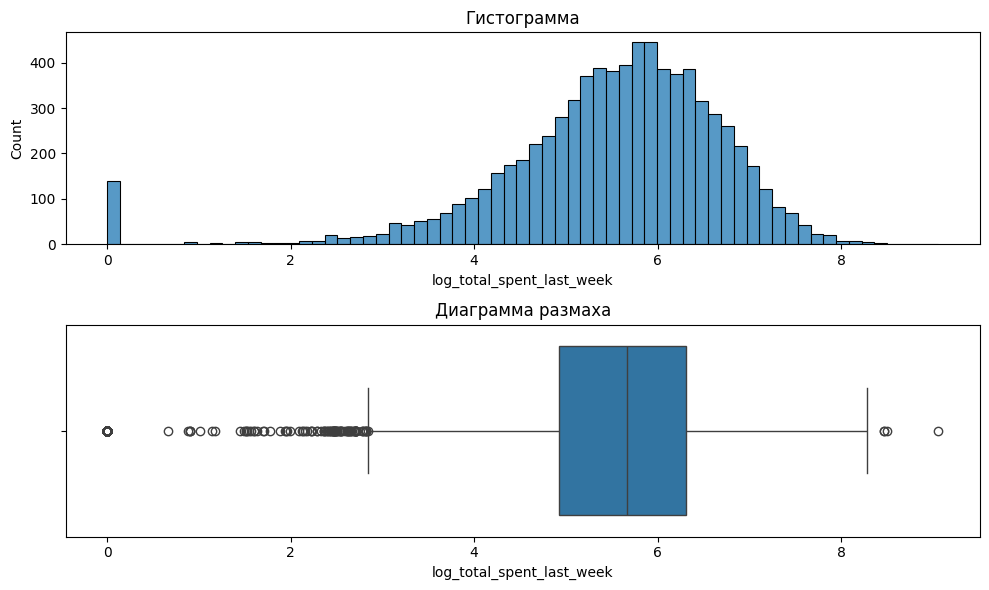

In [93]:
X1_train_val.loc[X1_train_val['total_spent_last_week'] < 0,'total_spent_last_week'] = 0
X1_train_val['log_total_spent_last_week'] = np.log1p(X1_train_val['total_spent_last_week'])
show_diagrams(X1_train_val, 'log_total_spent_last_week')

Распределение стало более равномерным, даже слекга скошенным влево. Правда, теперь есть выбросы в левую сторону, но они небольшие. Пересчитаем модель с учетом новой колонки:

In [94]:
num_col1 = num_col.copy()
num_col1.append('log_total_spent_last_week')
exc_col.append('log_total_spent_last_week')

work_model(LogisticRegression(max_iter=400), cat_transformer, num_transformer,
           X1_train_val, y_train_val, cat_col, num_col1, ['LogisticRegression','log_total_spent_last_week',''], res_df)
res_df

C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\287454607.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future ve

,Модель,Новые признаки,Гиперпараметры,PR AUC,CV%
0,DummyClassifier,,,0.0602,0.49
1,LogisticRegression,,,0.6876,7.15
2,LogisticRegression,log_total_spent_last_week,,0.6865,6.98


Добавление колонки не привело к улучшению модели: коэффициент метрки уменьшился. Зато стабильность модели чуть-чуть подросла. <a id='add2'></a>Другой кандидат на улучшеник структуры статистического распределения это колонка `avg_order_value` (средний чек, в рублях). Первоначальные диаграммы распределения выглядят следующим образом:

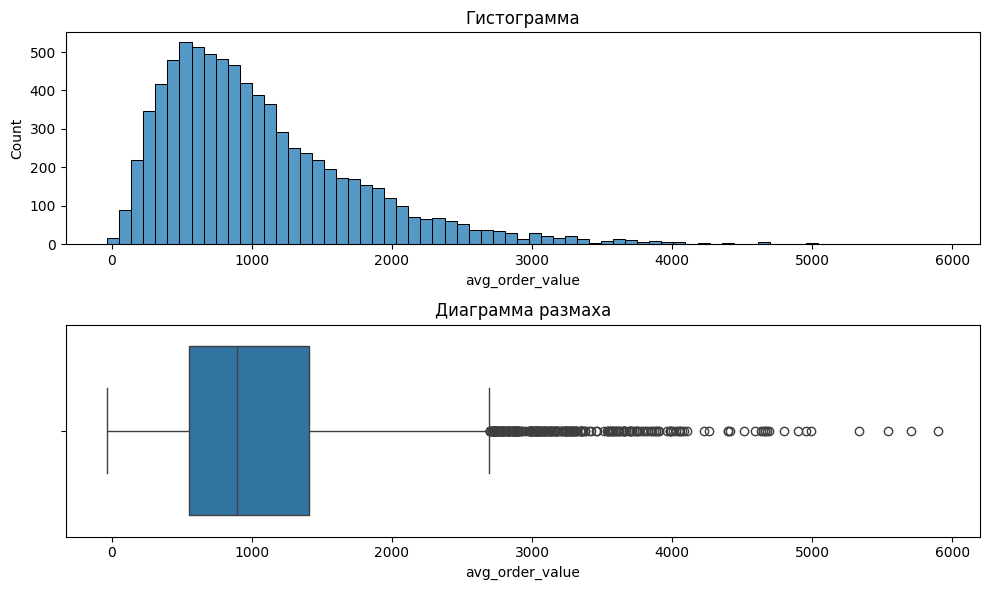

In [95]:
show_diagrams(X1_train_val, 'avg_order_value')

Распределение скошено вправо, много выбросов, абсолюные значения достаточно большие. Правда, в этом случае перекос не такой сильный поэтому можно предложить для преобразования использование квадратного корня.

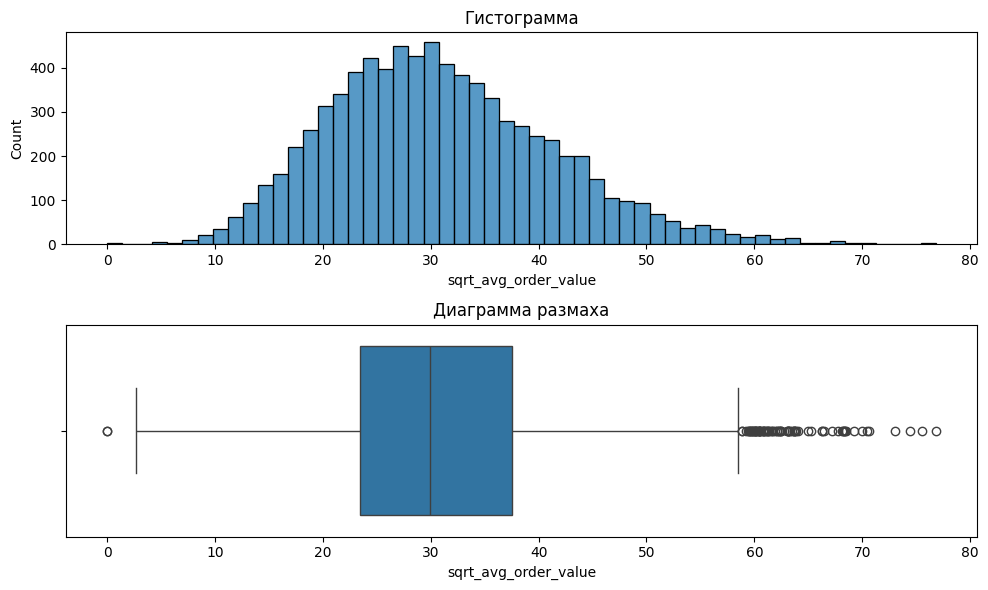

In [96]:
X1_train_val.loc[X1_train_val['avg_order_value'] < 0,'avg_order_value'] = 0
X1_train_val['sqrt_avg_order_value'] = np.sqrt(X1_train_val['avg_order_value'])
show_diagrams(X1_train_val, 'sqrt_avg_order_value')

Распределение стало похоже на нормальное, количество выбросов справа уменьшилось. Попробуем пересчитать модель с добавлением этой колонки:

In [97]:
num_col1.append('sqrt_avg_order_value')
exc_col.append('sqrt_avg_order_value')


work_model(LogisticRegression(max_iter=500), cat_transformer, num_transformer,
           X1_train_val, y_train_val, cat_col, num_col1,
           ['LogisticRegression','+sqrt_avg_order_value',''], res_df)
res_df

C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\287454607.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future ve

,Модель,Новые признаки,Гиперпараметры,PR AUC,CV%
0,DummyClassifier,,,0.0602,0.49
1,LogisticRegression,,,0.6876,7.15
2,LogisticRegression,log_total_spent_last_week,,0.6865,6.98
3,LogisticRegression,+sqrt_avg_order_value,,0.6846,7.39


Значение метрики немного уменьшилось - модель стала хуже. Уменьшилась и стабильность модели. 

Теперь попробуем поработать с категориальной колонкой. Колонку `app_crashes_last_month` (сколько раз приложение зависало за последний месяц) из дискретной можно преврать в бинарную со смыслом "зависало ли приложение в последний месяц". Тут придется переписать конвейер для предобработки категориальных данных.

In [98]:
# новая колонка
X1_train_val['yes_app_crach_last_month'] = np.where(X1_train_val['app_crashes_last_month'] > 0, 1, 0)
discrete_col1 = discrete_col.copy()
discrete_col1.append('yes_app_crach_last_month')

# Препроцессор для кодирования категориальных данных
cat_preproc = ColumnTransformer(
    transformers=[
        ('incode_onehot', OneHotEncoder(handle_unknown='ignore'), onehot_col),
        ('incode_target', TargetEncoder(), ['geo_location']),
        ('incode_no', SimpleImputer(missing_values=np.nan, strategy='constant',fill_value=0), 
             discrete_col1) # здесь добавлено, что для новой колонки не нужно кодирование
    ])

# Конвейер для предобработки категориальных данных
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('reset_df_index', FunctionTransformer(reset_df_index, validate=False)),
    ('cat_preproc', cat_preproc)
])

In [99]:
cat_col1 = cat_col.copy()
cat_col1.append('yes_app_crach_last_month')

work_model(LogisticRegression(max_iter=500), cat_transformer, num_transformer,
           X1_train_val, y_train_val, cat_col1, num_col1,
           ['LogisticRegression','+yes_app_crach_last_month',''], res_df)
res_df

C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\287454607.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future ve

,Модель,Новые признаки,Гиперпараметры,PR AUC,CV%
0,DummyClassifier,,,0.0602,0.49
1,LogisticRegression,,,0.6876,7.15
2,LogisticRegression,log_total_spent_last_week,,0.6865,6.98
3,LogisticRegression,+sqrt_avg_order_value,,0.6846,7.39
4,LogisticRegression,+yes_app_crach_last_month,,0.6984,6.95


Значение метрики модели с таким вариантом данных улучшилось. Кроме того она стала стабильнее. Теперь посмотрим кэффициенты послденей модели. По модулю они являются весами признаков. Т.е. признаки с малыми весами могут быть удалены из модели без нанесения ей ущерба.

C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\287454607.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")


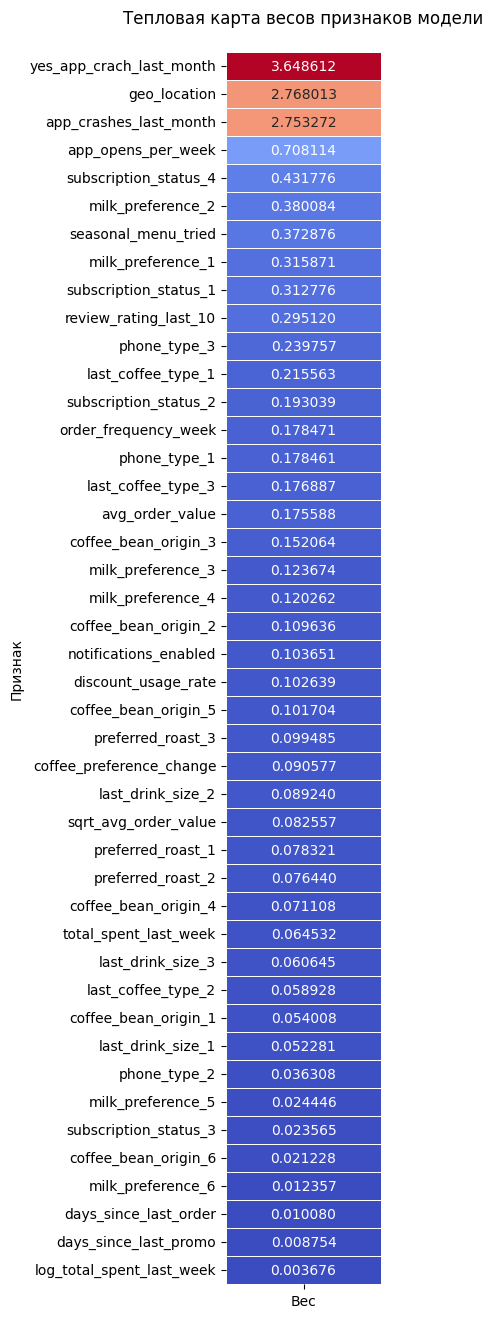

In [100]:
# Соберем предобработку данных и модель в один конвейер
prepocessor1 = ColumnTransformer(
    transformers=[
        ('cat', cat_transformer, cat_col1), # обработка категориальных данных
        ('num', num_transformer, num_col1)  # обработка числовых данных
])
    
pipeline1 = Pipeline(steps=[
    ('prep', prepocessor1),
    ('model', LogisticRegression(max_iter=500))
])

# Зададим параметры для пользовательских функций
pipeline1.steps[0][1].transformers[0][1].set_params(reset_df_index__kw_args={'X_orig': X1_train_val, 'cols_all':cat_col1})
pipeline1.steps[0][1].transformers[1][1].set_params(reset_df_index__kw_args={'X_orig': X1_train_val, 'cols_all':num_col1})

# Запустим обучение модели с предобработкой
pipeline1.fit(X1_train_val, y_train_val)
# Коэффициенты в виде списка
coef_l = list(pipeline1.steps[1][1].coef_[0])
# В список категориальных данных мы добавили yes_app_crach_last_month.
# Поэтому то же самое добавим в список категориальных колонок на выходе.
cat_mod_col1 = cat_mod_col.copy()
cat_mod_col1.append('yes_app_crach_last_month')
# В список числовых колонок на выходе добавим две придуманные нами колонки
num_mod_col1 = num_mod_col + ['log_total_spent_last_week', 'sqrt_avg_order_value']
# Соберем датафрейм весов признаков (коэффициентов регрессии)
# В нем поместим веса по модулю и отсортируем по их значениям
data1 = {'Признак': cat_mod_col1 + num_mod_col1, 
        'Вес': np.abs(coef_l)
        }
weight_df = pd.DataFrame(data1).sort_values('Вес', ascending=False)
weight_df.set_index('Признак', inplace=True)

# Строим тепловую карту
plt.figure(figsize=(2, 16))

sns.heatmap(weight_df,
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.6f', # Форматируем значения корреляции: три знака после точки
            cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5, # Форматируем линию между ячейками карты
            cbar=False # Отключаем цветовую шкалу
            #rot=0
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта весов признаков модели\n')

# Выводим график
plt.show()

Из тепловой карты весов следует, что наибольшее влияние на целевую переменную по мнению текущей модели имеют признаки, связанные с приложением и его сбоями. Причем, один из них мы добавили сами и он получил наибольший вес - 3.3621:
- `yes_app_crach_last_month` - в последний месяц было зависание приложения;
- `app_crashes_last_month` - сколько раз приложение зависало за последний месяц;
- `app_opens_per_week` - сколько раз за неделю пользователь в среднем открывал приложение доставки кофе.

Также большой вес имеет признак, связанный с регионом пользователя `geo_id`. Остальные признаки имею меньший вес.

Добавленные нами два числовых признака `log_total_spent_last_week` и `sqrt_avg_order_value` находятся в конце тепловой карты, так что с ними можно безболезненно расстаться. Кроме того, очень малые веса получили от модели признаки, которые уже до того имели нулевой коэффициент корреляции с целевой переменной. Это признаки: `days_since_last_promo`, `days_since_last_order` и `last_drink_size`. Удалим эти признаки и посмотрим, как будет работать модель.

In [101]:
num_col1.remove('sqrt_avg_order_value')
num_col1.remove('log_total_spent_last_week')

exc_col.remove('sqrt_avg_order_value')
exc_col.remove('log_total_spent_last_week')

cat_col1.remove('days_since_last_promo')
cat_col1.remove('days_since_last_order')
cat_col1.remove('last_drink_size')


X1_train_val.drop(['sqrt_avg_order_value', 'log_total_spent_last_week',
                   'days_since_last_promo', 'days_since_last_order', 'last_drink_size'], axis=1, inplace=True)

onehot_col1 = onehot_col.copy()
onehot_col1.remove('last_drink_size')
discrete_col1.remove('days_since_last_promo')
discrete_col1.remove('days_since_last_order')
# Пересоберем процессор обработки категориальных колонок
cat_preproc = ColumnTransformer(
    transformers=[
        ('incode_onehot', OneHotEncoder(handle_unknown='ignore'), onehot_col1),
        ('incode_target', TargetEncoder(), ['geo_location']),
        ('incode_no', SimpleImputer(missing_values=np.nan, strategy='constant',fill_value=0), 
             discrete_col1) # здесь добавлено, что для новой колонки не нужно кодирование
    ])

# Конвейер для предобработки категориальных данных
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('reset_df_index', FunctionTransformer(reset_df_index, validate=False)),
    ('cat_preproc', cat_preproc)
])

In [102]:
work_model(LogisticRegression(), cat_transformer, num_transformer,
           X1_train_val, y_train_val, cat_col1, num_col1,
           ['LogisticRegression','Удаление признаков',''], res_df)
res_df

C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\287454607.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future ve

,Модель,Новые признаки,Гиперпараметры,PR AUC,CV%
0,DummyClassifier,,,0.0602,0.49
1,LogisticRegression,,,0.6876,7.15
2,LogisticRegression,log_total_spent_last_week,,0.6865,6.98
3,LogisticRegression,+sqrt_avg_order_value,,0.6846,7.39
4,LogisticRegression,+yes_app_crach_last_month,,0.6984,6.95
5,LogisticRegression,Удаление признаков,,0.7027,6.70


Удаление вышеперечисленных признаков улучшило модель и ее устойчивость.

Итак, в текущем пункте была проделана следующая работа:
- К модели были добавлены три дополнителных признака. Причем, при добавлении каждого признака контролировалось состояние метрики модели. При доблавлении первых двух признаков `log_total_spent_last_week` и `sqrt_avg_order_value` качество модели только ухудшилось. Зато добавление последнего, третьего признака `yes_app_crach_last_month` улучшило качество модели.
- Были проанализированы абсолютные значения коэффициентов последней модели (они же веса признаков). При рассмотрении тепловой карты признаков было установлено, что наибольшее влияние на целевую переменную оказывают признаки, связанные с работоспособностью приложения доставки кофе. Кроме того, большое влияние на целевую переменную оказвает регион пользователя. Возможно, это тоже связано с разной работоспособность приложения в зависимости от региона.
- Из модели были удалены признаки с меньшими весами:
    - `log_total_spent_last_week` - вычисляемый признак, добавленный в модель ([см.выше](#add1)),
    - `sqrt_avg_order_value` - вычисляемый признак, добавленный в модель ([см.выше](#add2)),
    - `days_since_last_promo` - нулевой коэффициент корреляции с целевой переменной ([см.выше](#zero)),
    - `days_since_last_order` - нулевой коэффициент корреляции с целевой переменной ([см.выше](#zero)),
    - `last_drink_size` - нулевой коэффициент корреляции с целевой переменной ([см.выше](#zero)),

Удаление признаков благотворно сказалось на модели: метрика несколько увеличилась, устойчивость модели выросла.

*[Содержание](#sod)*

<a id='giper'></a>
## Этап 6. Эксперименты с гиперпараметрами

1. Перечислите все гиперпараметры, с которыми планируете экспериментировать.

2. Проведите систематический перебор гиперпараметров для `LogisticRegression`, выполните кросс-валидацию для каждой конфигурации.

3. Составьте таблицу с результатами.

4. Выберите лучшую модель, ориентируясь на заданную метрику качества.

Мы будем экспериментировать с коэффициентом регуляризации `C`. Рассмортим поведение модели с разными коэффициентами от `0.001` до `10`. Для кадого коэффициента будем проводить кросс-валидацию модели.

In [103]:
C_values = [0.001, 0.01, 0.1, 1., 5., 10.]

for cc in C_values:
    work_model(LogisticRegression(max_iter=300, C=cc), cat_transformer, num_transformer,
           X1_train_val, y_train_val, cat_col1, num_col1,
           ['LogisticRegression','Удаление признаков','C='+str(cc)], res_df)
res_df

C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\287454607.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future ve

,Модель,Новые признаки,Гиперпараметры,PR AUC,CV%
0,DummyClassifier,,,0.0602,0.49
1,LogisticRegression,,,0.6876,7.15
2,LogisticRegression,log_total_spent_last_week,,0.6865,6.98
3,LogisticRegression,+sqrt_avg_order_value,,0.6846,7.39
4,LogisticRegression,+yes_app_crach_last_month,,0.6984,6.95
5,LogisticRegression,Удаление признаков,,0.7027,6.70
6,LogisticRegression,Удаление признаков,C=0.001,0.6927,6.33
7,LogisticRegression,Удаление признаков,C=0.01,0.6976,6.52
8,LogisticRegression,Удаление признаков,C=0.1,0.7001,6.62
9,LogisticRegression,Удаление признаков,C=1.0,0.7027,6.70


Проведенная кросс-валидация показала, что для малых значений `C` (0.01) значение метрики значительно хуже, чем для предыдущей модели. Значение метрики растет до `C` = 1., затем начинает опять уменьшаться. Получается, что регуляризация для этой модели не нужна. Предварительно в качестве финальной модели выберем модель предыдущую модель без регуляризации.

*[Содержание](#sod)*

<a id='fin_mod'></a>
## Этап 7. Подготовка финальной модели

Объедините лучшую конфигурацию гиперпараметров с оптимальным набором признаков. Обучите модель на всех данных для кросс-валидации и проведите финальную оценку на отложенной тестовой выборке.


Теперь обучим предварительно выбранную модель по общим тестовым и валидационным данным.

In [104]:
# Соберем предобработку данных и модель в один конвейер
prepocessor1 = ColumnTransformer(
    transformers=[
        ('cat', cat_transformer, cat_col1), # обработка категориальных данных
        ('num', num_transformer, num_col1)  # обработка числовых данных
])
    
pipeline1 = Pipeline(steps=[
    ('prep', prepocessor1),
    ('model', LogisticRegression())
])

# Зададим параметры для пользовательских функций
pipeline1.steps[0][1].transformers[0][1].set_params(reset_df_index__kw_args={'X_orig': X1_train_val, 'cols_all':cat_col1})
pipeline1.steps[0][1].transformers[1][1].set_params(reset_df_index__kw_args={'X_orig': X1_train_val, 'cols_all':num_col1})

# Запустим обучение модели на обучающих + валидационных данных
pipeline1.fit(X1_train_val, y_train_val)
print('Обучение на обучающих + валидационных данных закончено.')

Обучение на обучающих + валидационных данных закончено.


C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\287454607.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")


Чтобы запустить проверку на тестовых данных, нужно предварительно добавить к ним вычсляемую колонку `yes_app_crach_last_month` и удалить колонки, от которых мы избавились при анализе весов признаков:

In [105]:
X1_test = X_test.copy()
# удаляем ненужные колонки
X1_test.drop(['days_since_last_promo', 'days_since_last_order', 'last_drink_size'], axis=1, inplace=True)

# новая колонка
X1_test['yes_app_crach_last_month'] = np.where(X1_test['app_crashes_last_month'] > 0, 1, 0)

y_pred_proba = pipeline1.predict_proba(X1_test)[:,1]
pr_auc_test = average_precision_score(y_test, y_pred_proba)
print(f'PR AUC (тестовые данные): {pr_auc_test:.4f}')

C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")


PR AUC (тестовые данные): 0.7365


C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\287454607.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")


На финальной модели для тестовых данных значение метрики `PR AUC` получилось лучше (0.7371), чем для остальных данных (0.7026). Однако, о недообучении речь не идет, так как разница значений метрики между общими и тестовыми данными всего 0.03. Что же касается общей оценки финальной метрики, то значение 0.7371 на тестовых данных значительно больше 0.5, что говорит о высоком качестве модели. Кроме того, при кросс-валидации финальная модель показала высокое значение коэффициента вализации CV% - 6.72% ( < 10%), что указывает на хорошую стабильность модели.

*[Содержание](#sod)*

<a id='otch'></a>
## Этап 8. Отчёт о проделанной работе

Проанализируйте итоговые метрики модели и факторы, которые на них повлияли. Составьте описание, выделив наиболее важные факторы.

В процессе работы над проектом была проделана следующая работа:
- При анализе целевой переменной `churn` был обнаружен очень большой дисбаланс классов целевой переменной (около 6% положительный класс), что пришлось учитывать на протяжении всего проекта.
- При первичном анализе данных было обрнаружено, что есть пары колонок с одинаковым смыслом, но с разными особенностями получения (разный временной период агрегации данных, разный метод расчета - средняя или медиана, разное количество заказов агрегации данных). Включение всех колонок из этих пар в модель неизбежно привело бы к мультиколинеарности.
- Так как в датафрейм данных входили разнородные данные (категориальные, числовые непрерывные, числовые дискретные), то для оценки связи между ними и целевой переменной были рассчитаны коэффициенты корреляции `phi_k`. Была построена тепловая карта коэффициентов корреляции для колонок. Для того, чтобы избежать мультиколинеарность, из числа признаков было исключено по одному признаку из упомянутых выше пар признаков с одинаковым смыслом, которые имели меньший коэффициент корреляции в паре. После удаления колонок был создан датафрем данных для моделирования. В нем из 26 колонок первоначального датафрейма осталось 21.
- В процессе проведения первичного анализа были определены способы заполнения пропусков и методы кодирования для категориальных признаков.
- Также во время проведения первичного анализа были рассмотрены параметры распределения числовых колонок для определения способов обработки выбросов при подготовке данных для моделирования. Для заполнения пропусков решено было пользоваться средними значениями по колонке.
- На этапе предобработки данных датафрейм для моделирования был разделен на матрицу признаков и вектор целевой переменной. После этого данные были разделены на тестовую выборку и остальные данные (данные для обучающей и валидационной выборки при проведении кросс-валидации).
- Далее был разработан препроцессор обработки колонок матрицы признаков. При этом матрица признаков была разделена на категориальные и числовые колонки, для каждого из двух типов был создан отдельный конвейер обработки колонок.
- При обработке категориальных колонок сначала заполнялись пропуски значением, наиболее часто встречающимся в колонке. Затем происходило кодирование колонок одним из методов `OneHotEncoder` (для колонок с маленьким числом уникальных значений) или `TargetEncoder` (для колонки `geo_location` - идентификатор региона, для которого уникальных значений много). Для дискретных числовых колонок кодирование не проводилось вовсе.
- При обработке числовых колонок сначала заполнялись пропуски средним значением из колонки. Вторым шагом обрабатывались выбросы для тех колонок, для которых это необходимо. Затем проводилось масштабирование колонок методом стандартизации.
- На этапе обучения модели сначал был создан датафрейм для хранения результатов кросс-валидации различных вариантов модели. Далее была написана функция, в которую передавались модель, препроцессоры предварительной обработки категориальных и числовых колонок, параметры сохранения результатов. Эта функция собирала модель обработки и препроцессоры предварительной обработки в единый общий конвейер, организовывала для этого общего конвейера кросс-валидацию при помощи функции `cross_validate`. Для оценки модели использовалась метрика `PR AUC`, указанная как рекомендуемая в задании к проекту. Усредненные значения метрики из массива значений для каждого шага кросс-валидации записывались в датафрейм результатов.
- Сначала при помощи функции расчета была получена метрика для базовой модели `DummyClassifier`. Таким образом, мы получили наихудший результат (PR AUC = 0.0602). Последующий расчет при помощи модели логистической регрессии `LogisticRegression` показал  результат PR AUC = 0.6878, что больше чем на порядок лучше по сравнению с базовой моделью.
- Для улучшения модели к матрице признаков были добавлены последовательно три вычисляемых признака:
    - `log_total_spent_last_week` - логарифм от значения колонки `total_spent_last_week` для улучшения сильно скошенного вправо распределения признака.
    - `sqrt_avg_order_value` - квадратный корень от значения колонки `avg_order_value`. В данном случае распределение было скошено вправо, но в меньшей степени, поэтому для его улучшения был применен квадратный корень
    - `yes_app_crach_last_month` - колонка с бинарными значениями, отражающими тот факт, что в последний месяц было зависание модели.
Первые два вычислительных признака не принесли улучшения модели. Последний признак улучшил модель.
- Были проанализированы абсолютные значения коэффициентов последней модели (они же веса признаков). При рассмотрении тепловой карты признаков было установлено, что наибольшее влияние на целевую переменную оказывают признаки, связанные с работоспособностью приложения доставки кофе. Кроме того, большое влияние на целевую переменную оказвает регион пользователя. Возможно, это тоже связано с разной работоспособность приложения в зависимости от региона.
- Из модели были удалены признаки с меньшими весами:
    - `log_total_spent_last_week` - вычисляемый признак, добавленный в модель ([см.выше](#add1))
    - `sqrt_avg_order_value` - вычисляемый признак, добавленный в модель ([см.выше](#add2)).
    - `days_since_last_promo` - нулевой коэффициент корреляции с целевой переменной ([см.выше](#zero)),
    - `days_since_last_order` - нулевой коэффициент корреляции с целевой переменной ([см.выше](#zero)),
    - `last_drink_size` - нулевой коэффициент корреляции с целевой переменной ([см.выше](#zero)),
- Удаление признаков благотворно сказалось на модели: метрика несколько увеличилась, устойчивость модели выросла.
- Были проверены варианты логистической модели с различными значениями гиперпараметра регуляризации `C`. Расчеты показали, что гиперпараметр регуляризации `C` влияет на модель в худшую сторону. Получилось, что регуляризация для этой модели не нужна. Предварительно в качестве финальной модели была выбрана модель без регуляризации.
- Было проведено обучение модели на обучающих+валидационных данных. Далее была получено предсказание и значение метрики `PR AUC` для тестовых данных. Это значение (0.7371) оказалось лучше, чем для финальной модели после кросс-валидации (0.7026). Однако, о недообучении речь не идет, так как разница значений метрики между общими и тестовыми данными всего 0.03. Что же касается общей оценки финальной метрики, то значение 0.7371 на тестовых данных значительно больше 0.5, что говорит о высоком качестве модели. Кроме того, при кросс-валидации финальная модель показала высокое значение коэффициента вализации CV% - 6.72% ( < 10%), что указывает на высокую стабильность модели.

*[Содержание](#sod)*

<a id='save'></a>
## Этап 9. Сохранение модели для продакшена

Сохраните итоговую модель и пайплайн предобработки. Убедитесь, что всё работает: загрузите артефакты и проверьте их на тестовых данных. В решении укажите ссылку для скачивания сохранённых файлов.

Для сохранения итоговой модели и паплайна для предобработки воспользуемся библиотекой `joblib`. Для выгрузки воспользуемся уже обученную модель из предыдущего этапа `pipeline1`. Файл сохранения назовём `customer_churn_model.joblib`, который будет выгружен в корневой каталог локального проекта:

In [106]:
joblib.dump(pipeline1, 'customer_churn_model.joblib')

['customer_churn_model.joblib']

Теперь загрузим общий конвейер с предобработкой и моделью из файла `customer_churn_model.joblib` и повторим процесс получения предсказаний для тестовых данных и расчета метрики оценки качества `PR AUC`:

In [107]:
loaded_model = joblib.load('customer_churn_model.joblib')
y_load_proba = pipeline1.predict_proba(X1_test)[:,1]
pr_auc_test_l = average_precision_score(y_test, y_load_proba)
print(f'PR AUC (тестовые данные - предобработанные данные и модель считаны): {pr_auc_test_l:.4f}')

PR AUC (тестовые данные - предобработанные данные и модель считаны): 0.7365


C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\3384108559.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")
C:\Users\victor8632\AppData\Local\Temp\ipykernel_22828\287454607.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X_df = X_df.apply(pd.to_numeric, errors="ignore")


Значение метрики получено такое же, как и в предыдущем этапе для модели до сохранения. Значит, запись и последующее чтение обученной модели через файл произошло успешно.

*[Содержание](#sod)*